# MediLearn: Module 4,5 — Agentic RAG & Multi-Agent Orchestration

1.   List item
2.   List item



## From Retrieval to Reasoning: Building an Intelligent Medical Learning System

> This module loads the fine-tuned model produced by Module 2 (saved to Google Drive) and the knowledge base built in Module 3. The Section 9 evaluation uses the **same fixed 60-question MediLearn set** used across Modules 1, 2, 3, and 6 — so the passive-RAG vs agentic-RAG comparison is directly anchored to the numbers from all earlier modules.

> **Module Progression**
> - Module 1: SLM Selection & Benchmarking
> - Module 2: Fine-Tuning on Medical Flashcards
> - Module 3: Medical RAG System *(Retrieval-Augmented Generation)*
> - **Module 4 (THIS MODULE): Agentic RAG + Multi-Agent Orchestration** ← You are here

---

## What We're Building

In Module 3 we built a *passive* RAG pipeline: query → embed → retrieve → generate. That's a fixed sequence with no decision-making.

In this module we transform that pipeline into an **Agentic System** that:
- **Reasons** about what to retrieve before retrieval
- **Reflects** on whether the retrieved documents are good enough
- **Plans** multi-step personalised learning paths
- **Simulates** dynamic clinical scenarios with real consequences
- **Orchestrates** all of the above with **LangGraph**

---

## Agents We Build

| Agent | Role | Key Agentic Property |
|---|---|---|
| **Agentic RAG Core** | Upgraded RAG with query rewriting & self-reflection | Loops until retrieval is sufficient |
| **Diagnostic Reasoner** | Socratic clinical tutor | Multi-turn statefulness, Socratic dialogue |
| **Study Planner** | Personalised curriculum builder | Persistent student memory, gap analysis |
| **Clinical Simulator** | Dynamic patient-case engine | Stateful patient model, consequence simulation |
| **Orchestrator** | Routes students to the right agent | Intent detection, multi-agent delegation |

---

## System Architecture

```
Student Input
      │
      ▼
┌─────────────────┐
│   Orchestrator  │  ← LangGraph StateGraph (top-level router)
└────────┬────────┘
         │ routes to one of:
    ┌────┴──────────────────────────────┐
    │            │            │         │
    ▼            ▼            ▼         ▼
Agentic RAG  Diagnostic  Study      Clinical
   Core      Reasoner    Planner    Simulator
    │            │            │         │
    └─────┬──────┘            │         │
          ▼                   ▼         ▼
     ChromaDB            Student    Patient
  (3 collections)         Memory     State
```


---

# Section 1: Setup & Installation

In [1]:
!pip install -q \
    transformers sentence-transformers chromadb \
    langchain langchain-community langchain-core \
    langgraph langchain-openai \
    accelerate bitsandbytes datasets \
    openai evaluate rouge_score trl peft \
    matplotlib pandas numpy scikit-learn

print("✓ All packages installed")


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
✓ All packages installed


In [2]:
import os, json, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, TypedDict
from datetime import datetime
from copy import deepcopy
from IPython.display import display, HTML

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END
import operator

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print("✓ Core libraries imported")

✓ Core libraries imported


---

# Section 2: Load Fine-Tuned SLM

In [3]:
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive mounted")
else:
    print("✅ Local environment: Google Drive mount not required.")


✅ Local environment: Google Drive mount not required.


In [4]:
# Load environment variables from local .env file if it exists
import os
env_path = os.path.abspath("../.env")
if os.path.exists(env_path):
    with open(env_path) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ[key.strip()] = val.strip().strip('"').strip("'")

import sys
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

IN_COLAB = "google.colab" in sys.modules
HF_BACKUP_MODEL = "sudhanshu-duke/smollm-135m-medical-finetuned"

local_path_1 = os.path.abspath("../SLM_Workshop/medical_slm_finetuned")
local_path_2 = "/content/drive/MyDrive/SLM Workshop/medical_slm_finetuned"

if os.path.exists(local_path_1):
    MODEL_PATH = local_path_1
elif IN_COLAB and os.path.exists(local_path_2):
    MODEL_PATH = local_path_2
else:
    MODEL_PATH = HF_BACKUP_MODEL

is_local = os.path.exists(MODEL_PATH)
is_hf_repo = "/" in MODEL_PATH and not os.path.exists(MODEL_PATH)

if not (is_local or is_hf_repo):
    raise FileNotFoundError(
        f"\n{'='*65}\n"
        f"Module 2's merged fine-tuned model not found at:\n  {MODEL_PATH}\n\n"
        f"Before running this notebook, complete Module 2 or ensure the HF backup model is accessible.\n"
        f"{'='*65}"
    )

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Loading from: {MODEL_PATH}")
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

slm_model = AutoModelForCausalLM.from_pretrained(
        MODEL_PATH,
        torch_dtype=torch.float16 if device in ["cuda", "mps"] else torch.float32,
        device_map="auto" if device == "cuda" else None,
        trust_remote_code=True
)
if device != "cuda":
    slm_model = slm_model.to(device)
slm_model.eval()
print(f"✅ SLM loaded — {sum(p.numel() for p in slm_model.parameters()):,} parameters")
print(f"   This is the Module 2 fine-tuned MediLearn model — Module 3 and Module 4 both use this.")


Loading from: /home/DHS-SLM-Workshop/SLM_Workshop/medical_slm_finetuned
Device: cuda


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

✅ SLM loaded — 81,430,848 parameters
   This is the Module 2 fine-tuned MediLearn model — Module 3 and Module 4 both use this.


In [5]:
def slm_generate(prompt: str, max_new_tokens: int = 256,
                 temperature: float = 0.3, do_sample: bool = True) -> str:
    inputs = tokenizer(prompt, return_tensors="pt",
                       truncation=True, max_length=1024).to(slm_model.device)
    with torch.no_grad():
        outputs = slm_model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            temperature=temperature, do_sample=do_sample,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.15)
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


def slm_chat(system_msg: str, user_msg: str, max_new_tokens: int = 300) -> str:
    prompt = (f"<|im_start|>system\n{system_msg}<|im_end|>\n"
              f"<|im_start|>user\n{user_msg}<|im_end|>\n"
              f"<|im_start|>assistant\n")
    return slm_generate(prompt, max_new_tokens=max_new_tokens)


test = slm_chat("You are a medical AI.", "What is septic shock in one sentence?")
print("✓ SLM inference working")
print(f"Test: {test[:200]}")

✓ SLM inference working
Test: Septic shock refers to a sudden loss of blood pressure or cardiac function, typically due to an infection or other underlying condition. This can occur when the body's immune system responds abnormall


---

## Section 2.5 — Shared MediLearn Evaluation Set (60 questions)

Same fixed set used in Modules 1, 2, 3, and 6. Loaded here so it's available when the Section 9 harness runs. The scoring functions are defined at Section 9 once the embedding model (loaded next in Section 3) is available.

In [6]:
# ── Shared MediLearn Evaluation Set ───────────────────────────────────────────
WORKSHOP_DIR = "/content/drive/MyDrive/SLM Workshop"
EVAL_DIR = f"{WORKSHOP_DIR}/eval"
DRIVE_RESULTS_DIR = f"{EVAL_DIR}/results"
os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)

MEDILEARN_EVAL_JSON = '''[{"id":"Q001","category":"Cardiology","difficulty":"L1","question":"What is the normal resting heart rate range for a healthy adult?","key_terms":["60","100","beats per minute","bpm"],"reference_answer":"A normal resting heart rate for adults is approximately 60-100 beats per minute."},{"id":"Q002","category":"Cardiology","difficulty":"L1","question":"What does the P wave represent on an ECG?","key_terms":["atrial","depolarization","p wave"],"reference_answer":"The P wave represents atrial depolarization, the electrical activation of the atria before they contract."},{"id":"Q003","category":"Cardiology","difficulty":"L1","question":"What do the S1 and S2 heart sounds represent?","key_terms":["mitral","tricuspid","aortic","pulmonic","valve closure"],"reference_answer":"S1 is caused by closure of the mitral and tricuspid valves at the start of systole; S2 is caused by closure of the aortic and pulmonic valves at the start of diastole."},{"id":"Q004","category":"Cardiology","difficulty":"L2","question":"A 58-year-old smoker presents with substernal chest pain radiating to the left arm, diaphoresis, and dyspnea. What is the most likely diagnosis and first-line antiplatelet therapy?","key_terms":["myocardial infarction","mi","acute coronary syndrome","aspirin","clopidogrel","p2y12"],"reference_answer":"This presentation is consistent with acute myocardial infarction (ACS). First-line antiplatelet therapy is aspirin, typically combined with a P2Y12 inhibitor such as clopidogrel."},{"id":"Q005","category":"Cardiology","difficulty":"L2","question":"What ECG finding distinguishes an NSTEMI from a STEMI?","key_terms":["st elevation","st segment","troponin","nstemi","stemi"],"reference_answer":"STEMI shows persistent ST-segment elevation on ECG, while NSTEMI does not show ST elevation but troponin is still elevated, indicating myocardial injury without complete vessel occlusion."},{"id":"Q006","category":"Cardiology","difficulty":"L2","question":"A patient with COPD presents with dyspnea, orthopnea, JVD, and an S3 gallop. What is the likely diagnosis and first-line medication class?","key_terms":["heart failure","diuretic","loop diuretic","fluid overload"],"reference_answer":"These findings suggest decompensated heart failure with volume overload. First-line treatment is a loop diuretic such as furosemide to reduce fluid overload."},{"id":"Q007","category":"Cardiology","difficulty":"L2","question":"What is the recommended blood pressure target for a patient with hypertension and chronic kidney disease per current guidelines?","key_terms":["130","80","mmhg","target"],"reference_answer":"Current guidelines generally recommend a blood pressure target below 130/80 mmHg for patients with hypertension and chronic kidney disease."},{"id":"Q008","category":"Cardiology","difficulty":"L3","question":"A 72-year-old with HFrEF (EF 30%) remains symptomatic despite an ACE inhibitor and beta-blocker. What two additional guideline-directed therapies should be considered, and why?","key_terms":["mineralocorticoid receptor antagonist","mra","sglt2 inhibitor","spironolactone","mortality benefit"],"reference_answer":"Guideline-directed therapy adds a mineralocorticoid receptor antagonist (e.g., spironolactone) and an SGLT2 inhibitor, both of which have demonstrated mortality and hospitalization benefit on top of ACE inhibitor and beta-blocker therapy in HFrEF."},{"id":"Q009","category":"Cardiology","difficulty":"L3","question":"Explain why beta-blockers are avoided in acute decompensated heart failure with cardiogenic shock but used in chronic stable heart failure.","key_terms":["negative inotrope","cardiac output","cardiogenic shock","chronic remodeling"],"reference_answer":"In acute cardiogenic shock, beta-blockers further reduce contractility and cardiac output, worsening hypoperfusion. In chronic stable heart failure, beta-blockers reduce sympathetic overdrive and adverse remodeling over time, improving long-term survival once the patient is hemodynamically stable."},{"id":"Q010","category":"Cardiology","difficulty":"L3","question":"A patient on warfarin presents with an INR of 8 and no active bleeding. What is the appropriate management?","key_terms":["hold warfarin","vitamin k","oral vitamin k","inr"],"reference_answer":"Warfarin should be held, and oral vitamin K should be administered to reduce the INR, since the patient is not actively bleeding and rapid reversal with clotting factors is not required."},{"id":"Q011","category":"Neurology","difficulty":"L1","question":"Which cranial nerves are primarily responsible for eye movement?","key_terms":["cranial nerve iii","oculomotor","trochlear","abducens","cn iv","cn vi"],"reference_answer":"Eye movement is controlled by cranial nerve III (oculomotor), IV (trochlear), and VI (abducens)."},{"id":"Q012","category":"Neurology","difficulty":"L1","question":"What is the primary function of the cerebellum?","key_terms":["coordination","balance","motor","fine motor control"],"reference_answer":"The cerebellum coordinates voluntary movement, balance, and fine motor control."},{"id":"Q013","category":"Neurology","difficulty":"L1","question":"Define aphasia and name its two major types.","key_terms":["aphasia","broca","wernicke","language"],"reference_answer":"Aphasia is an impairment of language production or comprehension. The two major types are Broca's (expressive) aphasia and Wernicke's (receptive) aphasia."},{"id":"Q014","category":"Neurology","difficulty":"L2","question":"A patient presents with sudden facial drooping, arm weakness, and aphasia. What is the diagnostic and treatment window for thrombolysis?","key_terms":["stroke","tpa","thrombolysis","4.5 hours","ct"],"reference_answer":"This presentation suggests acute ischemic stroke. After a non-contrast CT rules out hemorrhage, IV tPA (thrombolysis) can be given within 4.5 hours of symptom onset."},{"id":"Q015","category":"Neurology","difficulty":"L2","question":"What CSF findings differentiate bacterial from viral meningitis?","key_terms":["glucose","protein","neutrophil","lymphocyte","csf"],"reference_answer":"Bacterial meningitis typically shows low glucose, high protein, and neutrophil predominance in CSF, while viral meningitis shows normal glucose, mildly elevated protein, and lymphocyte predominance."},{"id":"Q016","category":"Neurology","difficulty":"L2","question":"A patient with diplopia, ptosis, and symptoms that improve with rest is suspected to have which neuromuscular disorder, and what test confirms it?","key_terms":["myasthenia gravis","acetylcholine receptor antibody","edrophonium","ice pack test"],"reference_answer":"This presentation is consistent with myasthenia gravis. It can be confirmed with acetylcholine receptor antibody testing or the edrophonium (Tensilon) test."},{"id":"Q017","category":"Neurology","difficulty":"L2","question":"What is the first-line treatment for status epilepticus?","key_terms":["benzodiazepine","lorazepam","diazepam","iv"],"reference_answer":"First-line treatment for status epilepticus is an IV benzodiazepine, such as lorazepam or diazepam."},{"id":"Q018","category":"Neurology","difficulty":"L3","question":"A patient presents with ascending symmetric weakness after a recent gastrointestinal infection. What is the diagnosis, expected CSF finding, and key treatment?","key_terms":["guillain-barre","albuminocytologic dissociation","ivig","plasmapheresis"],"reference_answer":"This is consistent with Guillain-Barre syndrome. CSF typically shows albuminocytologic dissociation (elevated protein with normal cell count). Treatment is IVIG or plasmapheresis."},{"id":"Q019","category":"Neurology","difficulty":"L3","question":"A 65-year-old presents with a sudden severe headache described as 'the worst of my life,' with no focal deficits, and a negative CT. What is the next diagnostic step, and what condition must be ruled out?","key_terms":["lumbar puncture","subarachnoid hemorrhage","xanthochromia"],"reference_answer":"The next step is a lumbar puncture to look for xanthochromia, since a sudden severe ('thunderclap') headache raises concern for subarachnoid hemorrhage even with a negative CT."},{"id":"Q020","category":"Neurology","difficulty":"L3","question":"Compare the mechanism and clinical use of IV thrombolysis versus mechanical thrombectomy in acute ischemic stroke, including time windows.","key_terms":["tpa","thrombectomy","4.5 hours","24 hours","large vessel occlusion"],"reference_answer":"IV thrombolysis (tPA) dissolves the clot pharmacologically and is given within 4.5 hours of onset. Mechanical thrombectomy physically removes the clot via catheter and can be used up to 24 hours in select patients with large vessel occlusion, often combined with tPA."},{"id":"Q021","category":"Respiratory","difficulty":"L1","question":"What is the normal respiratory rate range for a resting adult?","key_terms":["12","20","breaths per minute"],"reference_answer":"A normal resting respiratory rate for adults is approximately 12-20 breaths per minute."},{"id":"Q022","category":"Respiratory","difficulty":"L1","question":"What does a low FEV1/FVC ratio indicate, obstructive or restrictive lung disease?","key_terms":["obstructive","fev1","fvc","ratio"],"reference_answer":"A low FEV1/FVC ratio indicates an obstructive pattern, as seen in conditions like asthma and COPD."},{"id":"Q023","category":"Respiratory","difficulty":"L1","question":"What is the most common cause of community-acquired pneumonia in healthy adults?","key_terms":["streptococcus pneumoniae","strep pneumoniae","pneumococcus"],"reference_answer":"Streptococcus pneumoniae is the most common causative organism of community-acquired pneumonia in healthy adults."},{"id":"Q024","category":"Respiratory","difficulty":"L2","question":"A 16-year-old presents with severe wheezing, SpO2 85%, and is unable to speak full sentences. What is the immediate management for this asthma exacerbation?","key_terms":["oxygen","albuterol","bronchodilator","corticosteroid","nebulized"],"reference_answer":"Immediate management includes supplemental oxygen, nebulized short-acting beta-agonist (albuterol) bronchodilators, and systemic corticosteroids."},{"id":"Q025","category":"Respiratory","difficulty":"L2","question":"A 72-year-old presents with productive cough, fever, and right lower lobe consolidation on chest X-ray. What is the recommended outpatient antibiotic approach for community-acquired pneumonia?","key_terms":["amoxicillin","macrolide","doxycycline","outpatient"],"reference_answer":"For outpatient community-acquired pneumonia, recommended regimens include amoxicillin, or a macrolide/doxycycline, depending on comorbidities and local resistance patterns."},{"id":"Q026","category":"Respiratory","difficulty":"L2","question":"What distinguishes Type 1 from Type 2 respiratory failure based on arterial blood gas findings?","key_terms":["hypoxemia","hypercapnia","pao2","paco2"],"reference_answer":"Type 1 respiratory failure is characterized by hypoxemia with normal or low PaCO2, while Type 2 respiratory failure involves hypoxemia with hypercapnia (elevated PaCO2)."},{"id":"Q027","category":"Respiratory","difficulty":"L2","question":"What is the mechanism by which COPD leads to chronic CO2 retention?","key_terms":["air trapping","alveolar destruction","ventilation perfusion mismatch","hypoventilation"],"reference_answer":"Airway obstruction and alveolar destruction in COPD cause air trapping and ventilation-perfusion mismatch, reducing effective alveolar ventilation and leading to chronic CO2 retention over time."},{"id":"Q028","category":"Respiratory","difficulty":"L3","question":"A patient with ARDS is being mechanically ventilated. What ventilation strategy is recommended to reduce mortality, and why?","key_terms":["low tidal volume","6 ml/kg","lung protective","barotrauma"],"reference_answer":"A low tidal volume (lung-protective) ventilation strategy of approximately 6 mL/kg of predicted body weight is recommended, as it reduces ventilator-induced lung injury and barotrauma, improving survival."},{"id":"Q029","category":"Respiratory","difficulty":"L3","question":"Explain why supplemental oxygen must be titrated carefully in chronic CO2 retainers.","key_terms":["hypoxic drive","co2 retention","respiratory drive"],"reference_answer":"In chronic CO2 retainers, the respiratory drive may become more dependent on hypoxemia (hypoxic drive) rather than CO2 levels; excessive supplemental oxygen can blunt this drive and worsen hypoventilation and CO2 retention."},{"id":"Q030","category":"Respiratory","difficulty":"L3","question":"A patient with suspected pulmonary embolism has a low pretest probability. What is the appropriate diagnostic pathway?","key_terms":["d-dimer","ct pulmonary angiography","wells score","pretest probability"],"reference_answer":"With a low pretest probability, a D-dimer test is appropriate first; if negative, PE can generally be excluded without further imaging. If positive or pretest probability is higher, CT pulmonary angiography is the next step."},{"id":"Q031","category":"Endocrine","difficulty":"L1","question":"What hormone is deficient in Type 1 diabetes mellitus?","key_terms":["insulin","beta cell"],"reference_answer":"Type 1 diabetes mellitus results from autoimmune destruction of pancreatic beta cells, causing an absolute deficiency of insulin."},{"id":"Q032","category":"Endocrine","difficulty":"L1","question":"What is the function of thyroid hormones T3 and T4?","key_terms":["metabolism","metabolic rate","thyroid"],"reference_answer":"T3 and T4 regulate the body's metabolic rate, influencing heart rate, temperature, and energy expenditure."},{"id":"Q033","category":"Endocrine","difficulty":"L1","question":"What does HbA1c reflect?","key_terms":["average blood glucose","3 months","glycated hemoglobin"],"reference_answer":"HbA1c reflects average blood glucose levels over the preceding 2-3 months, based on glycation of hemoglobin."},{"id":"Q034","category":"Endocrine","difficulty":"L2","question":"A 22-year-old presents with 3 weeks of polyuria, polydipsia, and weight loss. What is the likely diagnosis and the initial management?","key_terms":["type 1 diabetes","insulin","new-onset diabetes"],"reference_answer":"This presentation suggests new-onset Type 1 diabetes mellitus. Initial management is insulin therapy, with evaluation for diabetic ketoacidosis."},{"id":"Q035","category":"Endocrine","difficulty":"L2","question":"A patient on diuretics presents with weakness, muscle cramps, and palpitations; potassium is 2.8. How should hypokalemia be corrected?","key_terms":["potassium replacement","oral potassium","iv potassium","ecg monitoring"],"reference_answer":"Hypokalemia should be corrected with oral or IV potassium replacement, with cardiac (ECG) monitoring given the risk of arrhythmia, and the underlying cause (diuretic use) addressed."},{"id":"Q036","category":"Endocrine","difficulty":"L2","question":"What are the diagnostic criteria for diabetic ketoacidosis (DKA)?","key_terms":["hyperglycemia","ketosis","metabolic acidosis","anion gap"],"reference_answer":"DKA is diagnosed by the triad of hyperglycemia, ketosis (elevated ketones), and metabolic acidosis with an elevated anion gap."},{"id":"Q037","category":"Endocrine","difficulty":"L2","question":"What is the first-line pharmacologic treatment for newly diagnosed Type 2 diabetes mellitus?","key_terms":["metformin"],"reference_answer":"Metformin is the first-line pharmacologic treatment for newly diagnosed Type 2 diabetes mellitus, alongside lifestyle modification."},{"id":"Q038","category":"Endocrine","difficulty":"L3","question":"A patient in DKA is being treated with IV insulin. What electrolyte must be monitored closely and corrected before or during insulin therapy, and why?","key_terms":["potassium","hypokalemia","intracellular shift"],"reference_answer":"Potassium must be monitored closely. Insulin drives potassium intracellularly, which can precipitate severe hypokalemia and arrhythmia if potassium is not replaced before or alongside insulin therapy."},{"id":"Q039","category":"Endocrine","difficulty":"L3","question":"Explain the mechanism by which SGLT2 inhibitors lower blood glucose and their additional cardiorenal benefits.","key_terms":["sglt2","glucose reabsorption","glycosuria","cardiorenal","heart failure"],"reference_answer":"SGLT2 inhibitors block glucose reabsorption in the proximal renal tubule, causing glycosuria and lowering blood glucose. They also reduce intraglomerular pressure and have demonstrated cardiorenal benefits, including reduced heart failure hospitalizations and slowed progression of chronic kidney disease."},{"id":"Q040","category":"Endocrine","difficulty":"L3","question":"Compare the clinical presentation and biochemical findings of SIADH versus diabetes insipidus.","key_terms":["siadh","diabetes insipidus","hyponatremia","hypernatremia","urine osmolality"],"reference_answer":"SIADH causes water retention, hyponatremia, and concentrated urine due to excess ADH. Diabetes insipidus causes excessive dilute urine output and hypernatremia due to insufficient ADH action, either central (deficient ADH) or nephrogenic (renal resistance to ADH)."},{"id":"Q041","category":"Critical Care","difficulty":"L1","question":"What are the classic signs of meningeal irritation on physical exam?","key_terms":["nuchal rigidity","kernig","brudzinski","neck stiffness"],"reference_answer":"Classic signs of meningeal irritation include nuchal rigidity (neck stiffness), a positive Kernig's sign, and a positive Brudzinski's sign."},{"id":"Q042","category":"Critical Care","difficulty":"L1","question":"Define sepsis according to the Sepsis-3 criteria.","key_terms":["life-threatening","organ dysfunction","infection","dysregulated response"],"reference_answer":"Sepsis-3 defines sepsis as life-threatening organ dysfunction caused by a dysregulated host response to infection."},{"id":"Q043","category":"Critical Care","difficulty":"L1","question":"What is the empiric antibiotic of choice for suspected bacterial meningitis in an adult?","key_terms":["ceftriaxone","vancomycin","empiric"],"reference_answer":"Empiric therapy for suspected bacterial meningitis in adults typically includes ceftriaxone plus vancomycin, often with dexamethasone."},{"id":"Q044","category":"Critical Care","difficulty":"L2","question":"A 54-year-old presents with septic shock from urosepsis (fever 40C, BP 88/52, HR 128). What are the key components of the sepsis bundle, and within what time frame should they be initiated?","key_terms":["blood cultures","lactate","fluids","antibiotics","1 hour"],"reference_answer":"The sepsis bundle includes obtaining blood cultures, measuring lactate, starting broad-spectrum antibiotics, and beginning IV fluid resuscitation, ideally all within the first hour of recognition."},{"id":"Q045","category":"Critical Care","difficulty":"L2","question":"What CSF glucose and protein pattern is expected in bacterial versus viral meningitis?","key_terms":["low glucose","high protein","bacterial","viral","normal glucose"],"reference_answer":"Bacterial meningitis typically shows low CSF glucose and high protein, while viral meningitis typically shows normal glucose and only mildly elevated protein."},{"id":"Q046","category":"Critical Care","difficulty":"L2","question":"A patient with septic shock remains hypotensive despite adequate fluid resuscitation. What is the first-line vasopressor?","key_terms":["norepinephrine","vasopressor"],"reference_answer":"Norepinephrine is the first-line vasopressor for septic shock that persists despite adequate fluid resuscitation."},{"id":"Q047","category":"Critical Care","difficulty":"L2","question":"What is the recommended timing for antibiotic administration in suspected septic shock?","key_terms":["1 hour","as soon as possible","broad-spectrum"],"reference_answer":"Broad-spectrum antibiotics should be administered as soon as possible, ideally within 1 hour of recognizing septic shock, after blood cultures are drawn."},{"id":"Q048","category":"Critical Care","difficulty":"L3","question":"Explain why early antibiotic administration in septic shock improves survival.","key_terms":["mortality","delay","golden hour","organ dysfunction"],"reference_answer":"Each hour of delay in appropriate antibiotic therapy during septic shock is associated with increased mortality, as ongoing untreated infection drives progressive organ dysfunction and hemodynamic collapse; early treatment interrupts this cascade."},{"id":"Q049","category":"Critical Care","difficulty":"L3","question":"A neutropenic febrile cancer patient presents with fever. What is the recommended empiric antibiotic approach, and why does timing matter so much in this population?","key_terms":["broad-spectrum","pseudomonas","neutropenic fever","immediate"],"reference_answer":"Neutropenic fever requires immediate broad-spectrum antibiotics with antipseudomonal coverage (e.g., cefepime or piperacillin-tazobactam), because these patients lack a normal immune response and can deteriorate rapidly from untreated infection."},{"id":"Q050","category":"Critical Care","difficulty":"L3","question":"Discuss the rationale for adding dexamethasone in bacterial meningitis treatment.","key_terms":["dexamethasone","inflammation","streptococcus pneumoniae","neurological outcome"],"reference_answer":"Dexamethasone is given alongside antibiotics in bacterial meningitis, particularly when Streptococcus pneumoniae is suspected, to reduce the inflammatory response to bacterial lysis and improve neurological outcomes, including reducing hearing loss."},{"id":"Q051","category":"Pharmacology","difficulty":"L1","question":"What is the mechanism of action of aspirin?","key_terms":["cox","cyclooxygenase","platelet","thromboxane"],"reference_answer":"Aspirin irreversibly inhibits cyclooxygenase (COX), reducing thromboxane A2 production and thereby inhibiting platelet aggregation."},{"id":"Q052","category":"Pharmacology","difficulty":"L1","question":"What class of drug is metformin, and what is its primary mechanism?","key_terms":["biguanide","hepatic glucose production","insulin sensitivity"],"reference_answer":"Metformin is a biguanide that primarily works by reducing hepatic glucose production and improving peripheral insulin sensitivity."},{"id":"Q053","category":"Pharmacology","difficulty":"L1","question":"What is the mechanism of action of beta-blockers in reducing cardiac workload?","key_terms":["beta receptor","heart rate","contractility","sympathetic"],"reference_answer":"Beta-blockers block beta-adrenergic receptors, reducing heart rate and contractility, which decreases myocardial oxygen demand and cardiac workload."},{"id":"Q054","category":"Pharmacology","difficulty":"L2","question":"What is the mechanism of action of ACE inhibitors and their primary clinical use?","key_terms":["angiotensin","vasodilation","hypertension","heart failure"],"reference_answer":"ACE inhibitors block conversion of angiotensin I to angiotensin II, reducing vasoconstriction and aldosterone release; they are primarily used for hypertension and heart failure."},{"id":"Q055","category":"Pharmacology","difficulty":"L2","question":"Why are NSAIDs contraindicated in patients with acute kidney injury or heart failure?","key_terms":["prostaglandin","renal perfusion","afferent arteriole"],"reference_answer":"NSAIDs inhibit prostaglandin synthesis, which normally maintains afferent arteriolar dilation and renal perfusion; blocking this can worsen renal perfusion and fluid retention in patients with AKI or heart failure."},{"id":"Q056","category":"Pharmacology","difficulty":"L2","question":"What is the mechanism by which loop diuretics cause hypokalemia?","key_terms":["loop of henle","sodium reabsorption","distal tubule","potassium loss"],"reference_answer":"Loop diuretics inhibit sodium reabsorption in the loop of Henle, increasing distal sodium delivery, which promotes sodium-potassium exchange in the distal tubule and increased urinary potassium loss."},{"id":"Q057","category":"Pharmacology","difficulty":"L2","question":"What are the major contraindications to thrombolytic therapy in acute ischemic stroke?","key_terms":["active bleeding","recent surgery","hemorrhage","anticoagulation"],"reference_answer":"Major contraindications include active internal bleeding, recent major surgery or trauma, history of intracranial hemorrhage, and current therapeutic anticoagulation, due to increased bleeding risk."},{"id":"Q058","category":"Pharmacology","difficulty":"L3","question":"Explain the mechanism of warfarin and why vitamin K alone is insufficient for emergent reversal in major bleeding.","key_terms":["vitamin k epoxide reductase","clotting factors","prothrombin complex concentrate"],"reference_answer":"Warfarin inhibits vitamin K epoxide reductase, blocking synthesis of clotting factors II, VII, IX, and X. Vitamin K administration alone takes hours to restore factor synthesis, so emergent major bleeding requires immediate factor replacement with prothrombin complex concentrate or fresh frozen plasma in addition to vitamin K."},{"id":"Q059","category":"Pharmacology","difficulty":"L3","question":"Compare the mechanisms of action of P2Y12 inhibitors and aspirin in preventing arterial thrombosis.","key_terms":["p2y12 receptor","adp","cyclooxygenase","platelet aggregation"],"reference_answer":"Aspirin inhibits cyclooxygenase to reduce thromboxane A2-mediated platelet activation, while P2Y12 inhibitors (e.g., clopidogrel) block the ADP receptor on platelets, preventing ADP-mediated platelet activation; together they provide complementary dual antiplatelet inhibition."},{"id":"Q060","category":"Pharmacology","difficulty":"L3","question":"Explain why combining ACE inhibitors with potassium-sparing diuretics increases the risk of hyperkalemia.","key_terms":["aldosterone","potassium retention","hyperkalemia","renin-angiotensin"],"reference_answer":"ACE inhibitors reduce aldosterone secretion, decreasing renal potassium excretion, while potassium-sparing diuretics directly block potassium excretion in the distal nephron; combining both mechanisms additively increases the risk of hyperkalemia and requires close potassium monitoring."}]'''

eval_set_path = f"{EVAL_DIR}/medilearn_eval_60.json"
if os.path.exists(eval_set_path):
    with open(eval_set_path) as f:
        MEDILEARN_QUESTIONS = json.load(f)
    print(f"✅ Loaded shared eval set from Drive: {eval_set_path}")
else:
    MEDILEARN_QUESTIONS = json.loads(MEDILEARN_EVAL_JSON)
    with open(eval_set_path, "w") as f:
        json.dump(MEDILEARN_QUESTIONS, f, indent=2)
    print(f"ℹ️  Initialized eval set from embedded copy → {eval_set_path}")

assert len(MEDILEARN_QUESTIONS) == 60
from collections import Counter
dc = Counter(q["difficulty"] for q in MEDILEARN_QUESTIONS)
print(f"   L1: {dc['L1']}  |  L2: {dc['L2']}  |  L3: {dc['L3']}  |  Total: 60")
print("   → Section 9 runs the full 60 questions for the passive-RAG vs agentic-RAG comparison.")

✅ Loaded shared eval set from Drive: /content/drive/MyDrive/SLM Workshop/eval/medilearn_eval_60.json
   L1: 18  |  L2: 24  |  L3: 18  |  Total: 60
   → Section 9 runs the full 60 questions for the passive-RAG vs agentic-RAG comparison.


---

# Section 3: Medical Knowledge Base (ChromaDB)

We rebuild the same three-collection ChromaDB from Module 3. This is the shared retrieval backbone for ALL agents.

In [7]:
from sentence_transformers import SentenceTransformer
import chromadb

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✓ Embedding model loaded: all-MiniLM-L6-v2")

CHROMA_PATH = "/content/chroma_medilearn_m4"
chroma_client = chromadb.PersistentClient(path=CHROMA_PATH)

cases_col     = chroma_client.get_or_create_collection("medical_cases")
guidelines_col= chroma_client.get_or_create_collection("clinical_guidelines")
knowledge_col = chroma_client.get_or_create_collection("medical_knowledge")

print(f"✓ ChromaDB initialised at {CHROMA_PATH}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ Embedding model loaded: all-MiniLM-L6-v2
✓ ChromaDB initialised at /content/chroma_medilearn_m4


In [8]:
# ── Clinical Cases Dataset ─────────────────────────────────────────────────────
case_based_dataset = [
    {"id":"case_001","patient_complaint":"Acute chest pain radiating to left arm",
     "history":"58M, smoker, hypertensive",
     "symptoms":"Severe substernal chest pain, diaphoresis, dyspnea 30 min",
     "physical_findings":"BP 145/92, HR 105, RR 22, S4 gallop",
     "diagnosis":"Acute Myocardial Infarction (STEMI)",
     "treatment":"Aspirin 325mg, clopidogrel 600mg, IV heparin, immediate PCI",
     "outcome":"Successful PCI with stent. Discharged on DAPT.",
     "clinical_pearls":"Time is muscle. Door-to-balloon <90 min improves outcomes."},
    {"id":"case_002","patient_complaint":"High fever and confusion",
     "history":"45F, recently hospitalised, immunocompromised",
     "symptoms":"Fever 39.5C, altered mental status, neck stiffness, photophobia",
     "physical_findings":"Petechial rash, nuchal rigidity, Kernig positive",
     "diagnosis":"Bacterial Meningitis (N. meningitidis)",
     "treatment":"Ceftriaxone 2g IV q12h, ampicillin 2g IV q4h, dexamethasone",
     "outcome":"Rapid antibiotics prevented complications. Hearing intact.",
     "clinical_pearls":"Start antibiotics BEFORE LP if meningitis suspected."},
    {"id":"case_003","patient_complaint":"Shortness of breath and rapid heartbeat",
     "history":"72M with COPD and diabetes",
     "symptoms":"Progressive dyspnea, orthopnea, PND, leg swelling",
     "physical_findings":"HR 115, JVD, bilateral crackles, peripheral oedema, S3",
     "diagnosis":"Acute Decompensated Heart Failure (HFrEF)",
     "treatment":"IV furosemide, ACE inhibitor, beta-blocker",
     "outcome":"Improved with diuresis. EF improved to 35%.",
     "clinical_pearls":"Check BNP and ECG. ICD if EF <35% after 40 days."},
    {"id":"case_004","patient_complaint":"Cough with fever and sputum",
     "history":"82F nursing home resident with dementia",
     "symptoms":"Green sputum, fever 38.5C, SOB, worsening confusion",
     "physical_findings":"Crackles RLL, consolidation, SpO2 88% on RA",
     "diagnosis":"Community-Acquired Pneumonia (CAP)",
     "treatment":"Ceftriaxone 1g IV + azithromycin 500mg IV, oxygen",
     "outcome":"Improvement day 3. Discharged day 5.",
     "clinical_pearls":"CURB-65 for severity. Antibiotics within 1 hour."},
    {"id":"case_005","patient_complaint":"Weakness and palpitations",
     "history":"35F on diuretics for hypertension",
     "symptoms":"General weakness, muscle cramps, palpitations, nausea",
     "physical_findings":"BP 98/60, HR 112, muscle weakness, decreased reflexes",
     "diagnosis":"Hypokalemia (K+ = 2.8 mEq/L)",
     "treatment":"IV KCl 20-40 mEq, ECG monitoring, K+-sparing diuretic",
     "outcome":"K+ normalised to 4.2. Symptoms resolved.",
     "clinical_pearls":"K+ <3.0 needs IV repletion. Always monitor ECG."},
    {"id":"case_006","patient_complaint":"Dizziness and loss of consciousness",
     "history":"68M with hypertension and smoking",
     "symptoms":"Sudden vertigo, facial drooping, slurred speech, right-sided weakness",
     "physical_findings":"NIHSS 15, right facial droop, arm drift, aphasia",
     "diagnosis":"Acute Ischaemic Stroke (left MCA territory)",
     "treatment":"IV tPA 0.9 mg/kg, aspirin, BP management",
     "outcome":"Thrombolysis successful. NIHSS improved to 3.",
     "clinical_pearls":"Time is brain. Door-to-thrombolysis <60 min."},
    {"id":"case_007","patient_complaint":"Polyuria, polydipsia, weight loss",
     "history":"22-year-old previously healthy student",
     "symptoms":"3-week history of polyuria, thirst, fatigue, 5 lb weight loss",
     "physical_findings":"HR 92, dry mucous membranes",
     "diagnosis":"Type 1 Diabetes Mellitus (new onset)",
     "treatment":"Basal-bolus insulin, diabetes education, dietary counselling",
     "outcome":"HbA1c 7.2% after 3 months.",
     "clinical_pearls":"Start insulin promptly. Self-monitoring essential."},
    {"id":"case_008","patient_complaint":"Sudden wheezing and dyspnea",
     "history":"16-year-old with childhood asthma",
     "symptoms":"Acute dyspnea, chest tightness, unable to speak full sentences",
     "physical_findings":"SpO2 85%, diffuse wheezing, accessory muscle use, PF <40%",
     "diagnosis":"Acute Severe Asthma Exacerbation",
     "treatment":"Albuterol nebulised q20min x3, methylprednisolone 125mg IV, magnesium 2g IV",
     "outcome":"Rapid improvement. Discharged on prednisone taper.",
     "clinical_pearls":"Silent chest + altered mental status = ICU."},
    {"id":"case_009","patient_complaint":"Fever, chills, and hypotension",
     "history":"54M with recurrent UTIs, urinary catheter in place",
     "symptoms":"Fever 40C, rigors, confusion, dysuria, hypotension, tachycardia",
     "physical_findings":"BP 88/52, HR 128, RR 28, cloudy urine",
     "diagnosis":"Septic Shock (urosepsis)",
     "treatment":"30 mL/kg crystalloid, broad-spectrum antibiotics, vasopressors, remove catheter",
     "outcome":"ICU admission, extubated day 3.",
     "clinical_pearls":"Sepsis bundle: cultures, antibiotics <1h, fluids, vasopressors."},
    {"id":"case_010","patient_complaint":"Elevated home BP readings",
     "history":"52F, overweight, sedentary",
     "symptoms":"Asymptomatic. Home BP 150-160/95-100 for 3 months.",
     "physical_findings":"Office BP 152/98, HR 78, no end-organ damage",
     "diagnosis":"Primary Hypertension (Stage 2)",
     "treatment":"Lifestyle modifications, lisinopril 10mg, reassess 4 weeks",
     "outcome":"BP 135/85 after 8 weeks.",
     "clinical_pearls":"Confirm with home readings. Target <130/80. Lifestyle critical."}
]

print(f"✓ Cases: {len(case_based_dataset)}")

✓ Cases: 10


In [9]:
# ── Clinical Guidelines Dataset ────────────────────────────────────────────────
clinical_guidelines = [
    {"id":"gl_001","condition":"Acute Myocardial Infarction",
     "diagnostic_criteria":"Elevated troponin + ischaemic symptoms + ECG changes (ST elevation, LBBB)",
     "treatment_protocol":"DAPT, beta-blockers, ACE-I, statins, PCI <90 min",
     "dosage":"Aspirin 325mg load, clopidogrel 600mg load, atorvastatin 80mg daily",
     "contraindications":"Thrombolytics if >12h from onset; NSAIDs",
     "monitoring":"Serial troponin 0/3/6/12h; echo; stress test before discharge"},
    {"id":"gl_002","condition":"Bacterial Meningitis",
     "diagnostic_criteria":"Meningeal signs + CSF protein >100, glucose <40, WBC >1000 PMN",
     "treatment_protocol":"Ceftriaxone + ampicillin + vancomycin + dexamethasone",
     "dosage":"Ceftriaxone 2g q12h; vancomycin 15-20 mg/kg q8-12h; dexamethasone 10mg q6h x4d",
     "contraindications":"Delay LP if raised ICP",
     "monitoring":"Repeat LP 48h if not improving; audiometry at 4 weeks"},
    {"id":"gl_003","condition":"Heart Failure (HFrEF)",
     "diagnostic_criteria":"EF <=40% + congestion symptoms",
     "treatment_protocol":"ACE-I/ARB/ARNI + beta-blockers + MRA + diuretics; ICD if EF <=35%",
     "dosage":"Lisinopril 5mg daily; carvedilol 3.125mg daily; spironolactone 12.5mg daily",
     "contraindications":"NSAIDs; thiazolidinediones; combined ACE-I + ARB",
     "monitoring":"BNP; echo q6-12mo; electrolytes monthly"},
    {"id":"gl_004","condition":"Community-Acquired Pneumonia",
     "diagnostic_criteria":"Respiratory symptoms + radiographic infiltrate + >=2 of fever, cough, sputum, dyspnea",
     "treatment_protocol":"Outpatient: amox-clav. Inpatient: cephalosporin + macrolide or fluoroquinolone",
     "dosage":"Ceftriaxone 1g IV daily + azithromycin 500mg IV daily",
     "contraindications":"Avoid beta-lactams if penicillin anaphylaxis",
     "monitoring":"CXR 4-6 weeks; reassess 48-72h"},
    {"id":"gl_005","condition":"Septic Shock",
     "diagnostic_criteria":"SIRS + infection + hypotension requiring vasopressors despite fluids",
     "treatment_protocol":"Sepsis bundle: lactate, cultures, antibiotics <1h, 30mL/kg fluid, vasopressors",
     "dosage":"NS 30mL/kg; norepinephrine 0.1 mcg/kg/min; broad-spectrum antibiotics",
     "contraindications":"Do not delay antibiotics for cultures",
     "monitoring":"Lactate q2-4h (goal >40% reduction at 6h); CVP/ScvO2; source control"},
    {"id":"gl_006","condition":"Acute Ischaemic Stroke",
     "diagnostic_criteria":"Acute neurological deficit + ischaemia on CT/MRI",
     "treatment_protocol":"IV tPA if <4.5h; thrombectomy if <24h (DAWN/DEFUSE3)",
     "dosage":"IV tPA 0.9mg/kg max 90mg: 10% bolus, remainder over 60 min",
     "contraindications":"Recent surgery; ICH; BP >185/110; recent anticoagulation",
     "monitoring":"NIHSS at baseline/24h/discharge; BP q15min x2h; head CT 24h"},
    {"id":"gl_007","condition":"Type 1 Diabetes Mellitus",
     "diagnostic_criteria":"Fasting glucose >=126 OR 2h OGTT >=200 OR random >=200 + symptoms",
     "treatment_protocol":"Basal-bolus insulin; CGM recommended",
     "dosage":"0.5-1 unit/kg/day TDD; basal 50%, bolus before meals",
     "contraindications":"No oral agents as monotherapy in T1DM",
     "monitoring":"HbA1c q3m (target 7%); SMBG 4-6x daily; lipids yearly"},
    {"id":"gl_008","condition":"Acute Severe Asthma",
     "diagnostic_criteria":"Peak flow <40%, severe dyspnea, cannot speak sentences, SpO2 <90%",
     "treatment_protocol":"High-dose beta-2 agonists + systemic corticosteroids + IV magnesium",
     "dosage":"Albuterol 2.5mg q20min x3; methylprednisolone 125mg IV; magnesium 2g IV",
     "contraindications":"Avoid beta-blockers; NSAIDs may trigger",
     "monitoring":"SpO2 continuously; peak flow q4-6h; ABG if no improvement 1h"},
    {"id":"gl_009","condition":"Hypokalemia",
     "diagnostic_criteria":"Serum K+ <3.5 mEq/L; severe if <2.5 with ECG changes",
     "treatment_protocol":"Mild: oral; Moderate: IV or oral; Severe: IV with cardiac monitoring",
     "dosage":"Mild: KCl 20-40 mEq PO; Moderate: 40-60 mEq IV over 2-4h; Severe: 20 mEq/h central",
     "contraindications":"Do not exceed 20 mEq/h peripheral; avoid in oliguria",
     "monitoring":"Repeat K+ after each dose; ECG if <2.5; address cause"},
    {"id":"gl_010","condition":"Primary Hypertension",
     "diagnostic_criteria":"Office SBP >=140/90 or home BP >=130/80 on >=2 days",
     "treatment_protocol":"Lifestyle + ACE-I, ARB, CCB, or thiazide",
     "dosage":"Lisinopril 10mg daily; amlodipine 5mg daily; HCTZ 25mg daily",
     "contraindications":"ACE-I/ARB in pregnancy; thiazides worsen gout; NSAIDs reduce effect",
     "monitoring":"Home BP monitoring; follow-up 4-6 weeks"}
]

print(f"✓ Guidelines: {len(clinical_guidelines)}")

✓ Guidelines: 10


In [10]:
# ── Knowledge Synthesis Dataset ────────────────────────────────────────────────
knowledge_synthesis = [
    {"id":"kn_001","topic":"Chest Pain Pathophysiology",
     "pathophysiology":"Myocardial ischaemia from plaque rupture. Anaerobic metabolism produces lactate. Necrosis begins 20-40 min from onset.",
     "misconceptions":"Myth: Troponin elevation always means MI. Reality: rises in sepsis, PE, renal failure. Myth: No ST elevation = no MI. Reality: NSTEMI is common.",
     "lab_interpretation":"Troponin rises 2-4h, peaks 24-48h. ECG shows regional pattern. BNP elevated in cardiogenic shock."},
    {"id":"kn_002","topic":"Sepsis and Systemic Inflammation",
     "pathophysiology":"Pathogen recognition triggers IL-6, TNF-alpha, IL-1beta. Vasodilation, permeability increase, microthrombi. Distributive shock: tissue hypoperfusion despite high CO.",
     "misconceptions":"Myth: Sepsis always has high fever. Reality: hypothermia (<36C) is worse prognostically. Myth: More fluids always better. Reality: fluid overload increases mortality.",
     "lab_interpretation":"Lactate >2 mmol/L: tissue hypoperfusion. Procalcitonin >0.5: bacterial. Thrombocytopenia: poor prognostic sign."},
    {"id":"kn_003","topic":"Potassium and Hypokalemia",
     "pathophysiology":"K+ critical for resting membrane potential. Na/K-ATPase maintains gradient. Hypokalemia makes membrane more negative, increasing arrhythmia risk.",
     "misconceptions":"Myth: Always treat K+ <3.5. Reality: symptoms matter more. Myth: Treat rapidly. Reality: too-fast repletion causes hyperkalaemia.",
     "lab_interpretation":"ECG: U waves, flat T waves, prolonged QT. Alkalosis shifts K+ intracellularly."},
    {"id":"kn_004","topic":"Stroke Mechanisms and Penumbra",
     "pathophysiology":"Arterial occlusion stops flow. ATP depletion fails Na/K pump causing cytotoxic oedema. Penumbra is salvageable. Every minute ~2 million neurons lost.",
     "misconceptions":"Myth: tPA equally effective at all times. Reality: benefit decreases after 4.5h. Myth: High bleeding risk. Reality: <1% symptomatic ICH with proper selection.",
     "lab_interpretation":"DWI hyperintense, ADC hypointense for acute ischaemia. NIHSS >20 = poor outcome."},
    {"id":"kn_005","topic":"Type 1 vs Type 2 Diabetes",
     "pathophysiology":"T1DM: autoimmune beta-cell destruction = absolute insulin deficiency. T2DM: insulin resistance + compensatory hypersecretion then exhaustion.",
     "misconceptions":"Myth: Type 2 is mild. Reality: both cause serious complications. Myth: Can switch from insulin to oral in T1. Reality: insulin lifelong in T1DM.",
     "lab_interpretation":"C-peptide: low in T1, normal/high in T2. GAD-65 and IA-2 antibodies confirm T1. HbA1c >=6.5% diagnostic."},
    {"id":"kn_006","topic":"Asthma Pathophysiology",
     "pathophysiology":"Th2-driven inflammation. IL-4/IL-5 promote eosinophil infiltration and IgE. Mast cell degranulation releases histamine, leukotrienes. Smooth muscle constriction, mucus plugging.",
     "misconceptions":"Myth: Asthma is purely allergic. Reality: non-allergic asthma exists. Myth: LABA monotherapy safe. Reality: LABA without ICS increases mortality.",
     "lab_interpretation":"FEV1/FVC <0.70: obstruction. Peak flow <50%: severe. Eosinophil >300: eosinophilic asthma."},
    {"id":"kn_007","topic":"Heart Failure Neurohormonal Activation",
     "pathophysiology":"Reduced CO triggers RAAS (Ang-II, aldosterone) and SNS (norepinephrine). Maladaptive: vasoconstriction, hypertrophy, fibrosis, apoptosis.",
     "misconceptions":"Myth: Diuretics alone treat HF. Reality: neurohormonal agents improve survival. Myth: All HF needs ICD. Reality: only EF <=35% after 40 days optimised.",
     "lab_interpretation":"BNP/NT-proBNP elevated. Echo: EF <40%. Hyponatraemia: severe activation."},
    {"id":"kn_008","topic":"Pneumonia and Host Defence",
     "pathophysiology":"Pathogens implant in alveoli. IL-8, TNF-alpha recruit neutrophils causing consolidation.",
     "misconceptions":"Myth: All CXR infiltrates are bacterial. Reality: viral, fungal, atypical causes exist. Myth: Longer antibiotics better. Reality: 5-7 days effective for CAP.",
     "lab_interpretation":"CXR: lobar consolidation (bacterial), interstitial (viral/atypical). PCT >0.5: bacterial."},
    {"id":"kn_009","topic":"Meningitis and Blood-Brain Barrier",
     "pathophysiology":"Haematogenous spread + TLR activation → TNF-alpha, IL-6. BBB permeability increases, leukocyte infiltration, meningeal inflammation, vasculitis.",
     "misconceptions":"Myth: LP always required. Reality: blood cultures + empiric therapy can start immediately. Myth: Dexamethasone harmful. Reality: reduces mortality if given with first antibiotic dose.",
     "lab_interpretation":"CSF glucose <40% of serum (bacterial). PMN predominance bacterial vs lymphocyte viral. Gram stain/culture."},
    {"id":"kn_010","topic":"Hypertension and End-Organ Damage",
     "pathophysiology":"Chronic HTN: endothelial dysfunction, arterial stiffness, arteriolar remodelling. Glomerulosclerosis, LVH, white matter changes.",
     "misconceptions":"Myth: Medications always immediately needed. Reality: lifestyle is first-line. Myth: ACE-I + ARB can be combined. Reality: increases hyperkalaemia without benefit.",
     "lab_interpretation":"Proteinuria: renal damage. LVH on ECG. Retinal changes grade severity."}
]

print(f"✓ Knowledge entries: {len(knowledge_synthesis)}")

✓ Knowledge entries: 10


In [11]:
# ── Populate ChromaDB Collections ──────────────────────────────────────────────

def embed_texts(texts):
    return embedding_model.encode(texts, show_progress_bar=False).tolist()

def populate_collection(collection, docs, doc_type):
    ids, texts, metas = [], [], []
    for doc in docs:
        if doc_type == "case":
            text = (f"CLINICAL CASE: {doc['diagnosis']}\n"
                    f"Patient: {doc['history']}\nComplaint: {doc['patient_complaint']}\n"
                    f"Symptoms: {doc['symptoms']}\nFindings: {doc['physical_findings']}\n"
                    f"Treatment: {doc['treatment']}\nOutcome: {doc['outcome']}\n"
                    f"Pearl: {doc['clinical_pearls']}")
            meta = {"type": "case", "diagnosis": doc["diagnosis"]}
        elif doc_type == "guideline":
            text = (f"CLINICAL GUIDELINE: {doc['condition']}\n"
                    f"Criteria: {doc['diagnostic_criteria']}\nProtocol: {doc['treatment_protocol']}\n"
                    f"Dosage: {doc['dosage']}\nContraindications: {doc['contraindications']}\n"
                    f"Monitoring: {doc['monitoring']}")
            meta = {"type": "guideline", "condition": doc["condition"]}
        else:
            text = (f"MEDICAL KNOWLEDGE: {doc['topic']}\n"
                    f"Pathophysiology: {doc['pathophysiology']}\n"
                    f"Misconceptions: {doc['misconceptions']}\n"
                    f"Labs: {doc['lab_interpretation']}")
            meta = {"type": "knowledge", "topic": doc["topic"]}
        ids.append(doc["id"]); texts.append(text); metas.append(meta)
    collection.upsert(ids=ids, embeddings=embed_texts(texts), documents=texts, metadatas=metas)
    return len(ids)

n1 = populate_collection(cases_col,      case_based_dataset,  "case")
n2 = populate_collection(guidelines_col, clinical_guidelines, "guideline")
n3 = populate_collection(knowledge_col,  knowledge_synthesis, "knowledge")
print(f"✓ ChromaDB populated: {n1} cases | {n2} guidelines | {n3} knowledge = {n1+n2+n3} total")

✓ ChromaDB populated: 10 cases | 10 guidelines | 10 knowledge = 30 total


In [12]:
# ── Unified Retrieval Function (shared by all agents) ──────────────────────────

def retrieve(query: str, collection_names: List[str] = None, top_k: int = 3) -> List[Dict]:
    """Semantic retrieval across one or more ChromaDB collections."""
    if collection_names is None:
        collection_names = ["cases", "guidelines", "knowledge"]
    coll_map = {"cases": cases_col, "guidelines": guidelines_col, "knowledge": knowledge_col}
    q_emb = embedding_model.encode([query])[0].tolist()
    results = []
    for name in collection_names:
        if name not in coll_map: continue
        res = coll_map[name].query(query_embeddings=[q_emb], n_results=top_k,
                                   include=["documents","metadatas","distances"])
        for doc, meta, dist in zip(res["documents"][0], res["metadatas"][0], res["distances"][0]):
            results.append({"content": doc, "metadata": meta,
                            "similarity": 1.0 - dist, "collection": name})
    results.sort(key=lambda x: x["similarity"], reverse=True)
    return results

test = retrieve("chest pain heart attack", top_k=2)
print("✓ Retrieval working")
print(f"  Top result similarity: {test[0]['similarity']:.3f}")
print(f"  Top result preview: {test[0]['content'][:100]}...")

✓ Retrieval working
  Top result similarity: 0.166
  Top result preview: CLINICAL CASE: Acute Myocardial Infarction (STEMI)
Patient: 58M, smoker, hypertensive
Complaint: Acu...


---

# Section 4: Agentic RAG Core — From Passive to Active Retrieval

## The Transformation: Module 3 → Module 4

| | Module 3 (Passive RAG) | Module 4 (Agentic RAG) |
|---|---|---|
| **Query handling** | Raw query embedded directly | Query rewritten by agent |
| **Retrieval check** | Always use top-K results | Grader checks sufficiency |
| **Loops** | None — single pass | Can retry with better query |
| **Transparency** | No trace | Full reasoning trace |
| **Decision-making** | Zero | ReAct: Reason → Act → Observe |

The key addition is a **ReAct loop**:
```
query → REWRITE → RETRIEVE → GRADE → (sufficient?) → GENERATE
                    ↑_______________|  (not sufficient: loop)
```


In [13]:
# ── Agentic RAG State ──────────────────────────────────────────────────────────

class AgenticRAGState(TypedDict):
    original_query:       str
    rewritten_query:      str
    retrieved_docs:       List[Dict]
    retrieval_sufficient: bool
    generation:           str
    iterations:           int
    reasoning_trace:      List[str]

MAX_ITER    = 2      # Maximum retrieval loops
MIN_SIM     = 0.25   # Minimum acceptable similarity score

print("✓ AgenticRAGState defined")
print("  Fields:", list(AgenticRAGState.__annotations__.keys()))

✓ AgenticRAGState defined
  Fields: ['original_query', 'rewritten_query', 'retrieved_docs', 'retrieval_sufficient', 'generation', 'iterations', 'reasoning_trace']


In [14]:
# ── Node: Query Rewriter ────────────────────────────────────────────────────────
def node_rewrite(state: AgenticRAGState) -> AgenticRAGState:
    """Rewrite the student's query into a retrieval-optimised medical query."""
    q = state["original_query"]
    trace = list(state["reasoning_trace"])
    system = ("You are a medical retrieval expert. Rewrite the student's question "
              "into a precise, term-rich retrieval query. Output ONLY the rewritten query.")
    rewritten = slm_chat(system, f"Student question: {q}\nRewrite:", max_new_tokens=80)
    rewritten = rewritten.strip().split("\n")[0]
    if not rewritten or len(rewritten) < 5:
        rewritten = q
    trace.append(f"[Rewrite] '{q}' → '{rewritten}'")
    return {**state, "rewritten_query": rewritten, "reasoning_trace": trace}

# ── Node: Retriever ─────────────────────────────────────────────────────────────
def node_retrieve(state: AgenticRAGState) -> AgenticRAGState:
    """Semantic retrieval across all three ChromaDB collections."""
    q = state["rewritten_query"] or state["original_query"]
    trace = list(state["reasoning_trace"])
    docs = retrieve(q, top_k=3)
    top_sim = docs[0]["similarity"] if docs else 0
    trace.append(f"[Retrieve] {len(docs)} docs, top similarity: {top_sim:.3f}")
    return {**state, "retrieved_docs": docs, "reasoning_trace": trace}

# ── Node: Relevance Grader ──────────────────────────────────────────────────────
def node_grade(state: AgenticRAGState) -> AgenticRAGState:
    """Self-reflection: are the retrieved documents sufficient?"""
    docs      = state["retrieved_docs"]
    trace     = list(state["reasoning_trace"])
    iters     = state["iterations"]
    good      = [d for d in docs if d["similarity"] > MIN_SIM]
    sufficient = len(good) >= 2 or iters >= MAX_ITER
    trace.append(f"[Grade] Good docs: {len(good)}/{len(docs)} | Sufficient: {sufficient} | Iter: {iters}")
    return {**state, "retrieval_sufficient": sufficient,
            "iterations": iters + 1, "reasoning_trace": trace}

# ── Node: Generator ─────────────────────────────────────────────────────────────
def node_generate(state: AgenticRAGState) -> AgenticRAGState:
    """Generate a grounded, evidence-backed educational response."""
    q     = state["original_query"]
    docs  = state["retrieved_docs"]
    trace = list(state["reasoning_trace"])
    ctx   = "\n\n".join([f"[Source {i+1} – {d['collection']}]\n{d['content'][:400]}"
                           for i, d in enumerate(docs[:3])])
    system = ("You are a medical education AI tutor. Answer using ONLY the provided "
              "clinical context. Be educational, accurate, and structured.")
    user   = f"Clinical Context:\n{ctx}\n\nStudent Question: {q}\n\nEducational Answer:"
    response = slm_chat(system, user, max_new_tokens=350)
    trace.append(f"[Generate] Response: {len(response.split())} words")
    return {**state, "generation": response, "reasoning_trace": trace}

# ── Conditional Edge ────────────────────────────────────────────────────────────
def route_after_grade(state: AgenticRAGState) -> str:
    return "generate" if state["retrieval_sufficient"] else "rewrite"

print("✓ Agentic RAG nodes defined")

✓ Agentic RAG nodes defined


In [15]:
# ── Build & Compile Agentic RAG Graph ──────────────────────────────────────────

def build_agentic_rag():
    g = StateGraph(AgenticRAGState)
    g.add_node("rewrite",  node_rewrite)
    g.add_node("retrieve", node_retrieve)
    g.add_node("grade",    node_grade)
    g.add_node("generate", node_generate)
    g.set_entry_point("rewrite")
    g.add_edge("rewrite",  "retrieve")
    g.add_edge("retrieve", "grade")
    g.add_conditional_edges("grade", route_after_grade,
                            {"generate": "generate", "rewrite": "rewrite"})
    g.add_edge("generate", END)
    return g.compile()

agentic_rag = build_agentic_rag()

def run_agentic_rag(query: str, verbose: bool = True) -> Dict:
    state: AgenticRAGState = {
        "original_query": query, "rewritten_query": "",
        "retrieved_docs": [], "retrieval_sufficient": False,
        "generation": "", "iterations": 0, "reasoning_trace": []
    }
    result = agentic_rag.invoke(state)
    if verbose:
        print("\n" + "═"*65)
        print(f"AGENTIC RAG | Query: {query}")
        print("═"*65)
        print("Reasoning trace:")
        for step in result["reasoning_trace"]: print(f"  {step}")
        print("\nResponse:")
        print(result["generation"])
        print("═"*65)
    return result

# ── Demo ─────────────────────────────────────────────────────────────────────────
_ = run_agentic_rag("How do I manage a patient presenting with acute chest pain?")


═════════════════════════════════════════════════════════════════
AGENTIC RAG | Query: How do I manage a patient presenting with acute chest pain?
═════════════════════════════════════════════════════════════════
Reasoning trace:
  [Rewrite] 'How do I manage a patient presenting with acute chest pain?' → 'I can treat a patient who presents with acute chest pain by administering ibuprofen or acetaminophen. The patient is experiencing mild to moderate symptoms of fever and chills, which may be accompanied by other signs such as nausea, vomiting, and difficulty breathing. Ibuprofen and acetaminophen work quickly to reduce inflammation in the body, but it is important to note that these medications should not be used for long periods without proper monitoring due'
  [Retrieve] 9 docs, top similarity: -0.066
  [Grade] Good docs: 0/9 | Sufficient: False | Iter: 0
  [Rewrite] 'How do I manage a patient presenting with acute chest pain?' → 'I can handle this patient by providing 2 options for

---

# Section 5: Agent 1 — Diagnostic Reasoner (Socratic Tutor)

## Role
Instead of giving the answer directly, the Diagnostic Reasoner teaches **clinical reasoning** through Socratic dialogue:
1. Analyse the initial presentation
2. Retrieve similar real cases from ChromaDB
3. Build a differential diagnosis
4. Ask ONE targeted question to narrow the differential
5. Repeat until confident → reveal diagnosis + teaching points

## Graph Design
```
START → analyse → retrieve_cases → build_differential → socratic_q → check
                                                                         │
                                              (not resolved) ←───────────┘
                                              (resolved) → END
```


In [16]:
class DiagnosticState(TypedDict):
    conversation_history: List[Dict]
    patient_presentation: str
    differential_diagnosis: List[str]
    similar_cases: List[Dict]
    questions_asked: List[str]
    reasoning_chain: List[str]
    turn: int
    case_resolved: bool
    final_diagnosis: str
    next_question: str

print("✓ DiagnosticState defined")

✓ DiagnosticState defined


In [17]:
def diag_analyse(state: DiagnosticState) -> DiagnosticState:
    pres  = state["patient_presentation"]
    trace = list(state["reasoning_chain"])
    analysis = slm_chat(
        "You are a clinician. Extract key clinical features: age, sex, chief complaint, "
        "vital signs, red flags. Be concise.",
        f"Presentation: {pres}\nKey features:", max_new_tokens=120)
    trace.append(f"[Analysis] {analysis}")
    return {**state, "reasoning_chain": trace}


def diag_retrieve_cases(state: DiagnosticState) -> DiagnosticState:
    docs  = retrieve(state["patient_presentation"], collection_names=["cases","guidelines"], top_k=3)
    trace = list(state["reasoning_chain"])
    trace.append(f"[Retrieval] {len(docs)} similar cases/guidelines found")
    return {**state, "similar_cases": docs, "reasoning_chain": trace}


def diag_build_differential(state: DiagnosticState) -> DiagnosticState:
    pres    = state["patient_presentation"]
    docs    = state["similar_cases"]
    trace   = list(state["reasoning_chain"])
    history = state["conversation_history"]
    ctx     = "\n".join([d["content"][:250] for d in docs[:3]])
    hist    = "\n".join([f"{h['role'].upper()}: {h['content']}" for h in history[-4:]])
    diff_text = slm_chat(
        "You are a clinical educator. List TOP 3 most likely diagnoses in order. "
        "Format: 1. [Diagnosis] — [Key feature]. One line each.",
        f"Patient: {pres}\n\nSimilar cases:\n{ctx}\n\nConversation:\n{hist}\n\nTop 3 differential:",
        max_new_tokens=150)
    differential = [l.strip() for l in diff_text.split("\n")
                    if l.strip() and any(c.isalpha() for c in l)][:3]
    if not differential:
        differential = ["Insufficient information — need more details"]
    trace.append(f"[Differential] {' | '.join(differential[:3])}")
    return {**state, "differential_diagnosis": differential, "reasoning_chain": trace}


def diag_socratic_question(state: DiagnosticState) -> DiagnosticState:
    diff   = state["differential_diagnosis"]
    asked  = list(state["questions_asked"])
    trace  = list(state["reasoning_chain"])
    asked_txt = "; ".join(asked) if asked else "none"
    diff_txt  = "\n".join(diff[:3])
    question  = slm_chat(
        f"You are a Socratic medical tutor. Ask ONE targeted clinical question "
        f"to narrow the differential. Already asked: {asked_txt}",
        f"Patient: {state['patient_presentation']}\nDifferential:\n{diff_txt}\n\nNext question:",
        max_new_tokens=80)
    question = question.strip().split("\n")[0]
    asked.append(question)
    trace.append(f"[Socratic Q{len(asked)}] {question}")
    return {**state, "next_question": question, "questions_asked": asked, "reasoning_chain": trace}


def diag_check_resolve(state: DiagnosticState) -> DiagnosticState:
    trace = list(state["reasoning_chain"])
    turn  = state["turn"]
    resolved = turn >= 3
    if resolved:
        hist_text = " ".join([h["content"] for h in state["conversation_history"]])
        ctx  = "\n".join([d["content"][:200] for d in state["similar_cases"][:2]])
        final = slm_chat(
            "You are a clinical educator. State the most likely diagnosis with clinical "
            "reasoning. Summarise 2-3 key learning points.",
            f"Case: {hist_text}\n\nEvidence:\n{ctx}\n\nFinal diagnosis and teaching:",
            max_new_tokens=300)
        trace.append(f"[Resolved] Turn {turn}")
        return {**state, "case_resolved": True, "final_diagnosis": final, "reasoning_chain": trace}
    trace.append(f"[Check] Turn {turn}, continuing")
    return {**state, "case_resolved": False, "reasoning_chain": trace}


def route_diag(state: DiagnosticState) -> str:
    return "end" if state["case_resolved"] else "continue"


def build_diagnostic_graph():
    g = StateGraph(DiagnosticState)
    g.add_node("analyse",      diag_analyse)
    g.add_node("retrieve",     diag_retrieve_cases)
    g.add_node("differential", diag_build_differential)
    g.add_node("question",     diag_socratic_question)
    g.add_node("check",        diag_check_resolve)
    g.set_entry_point("analyse")
    g.add_edge("analyse",      "retrieve")
    g.add_edge("retrieve",     "differential")
    g.add_edge("differential", "question")
    g.add_edge("question",     "check")
    g.add_conditional_edges("check", route_diag, {"end": END, "continue": END})
    return g.compile()

diagnostic_graph = build_diagnostic_graph()
print("✓ Diagnostic Reasoner graph compiled")

✓ Diagnostic Reasoner graph compiled


In [18]:
class DiagnosticSession:
    """Manages multi-turn Socratic diagnostic dialogue with persistent state."""
    def __init__(self):
        self.state: DiagnosticState = {
            "conversation_history": [], "patient_presentation": "",
            "differential_diagnosis": [], "similar_cases": [],
            "questions_asked": [], "reasoning_chain": [],
            "turn": 0, "case_resolved": False,
            "final_diagnosis": "", "next_question": ""
        }

    def start(self, presentation: str) -> str:
        self.state["patient_presentation"] = presentation
        self.state["conversation_history"].append({"role": "student", "content": presentation})
        self.state = diagnostic_graph.invoke(self.state)
        q = self.state["next_question"]
        self.state["conversation_history"].append({"role": "agent", "content": q})
        return q

    def respond(self, answer: str) -> str:
        self.state["patient_presentation"] += f" | {answer}"
        self.state["conversation_history"].append({"role": "student", "content": answer})
        self.state["turn"] += 1
        self.state = diagnostic_graph.invoke(self.state)
        response = self.state["final_diagnosis"] if self.state["case_resolved"] else self.state["next_question"]
        self.state["conversation_history"].append({"role": "agent", "content": response})
        return response

    def get_trace(self): return self.state["reasoning_chain"]


# ── Demo ─────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("DEMO: Diagnostic Reasoner — Multi-Turn Socratic Dialogue")
print("=" * 65)

session = DiagnosticSession()
pres = "50-year-old male, worst headache of his life, sudden onset"
print(f"\nStudent (case): {pres}")
q1 = session.start(pres)
print(f"\nAgent (Q1):    {q1}")

a1 = "Neck stiffness and photophobia. No fever initially but now 38.5C."
print(f"\nStudent:       {a1}")
q2 = session.respond(a1)
print(f"\nAgent (Q2):    {q2}")

a2 = "No trauma. No recent travel. He takes no regular medications."
print(f"\nStudent:       {a2}")
final = session.respond(a2)
print(f"\nAgent (Final):\n{final}")

print("\n── Reasoning Trace ──")
for step in session.get_trace(): print(f"  {step}")

DEMO: Diagnostic Reasoner — Multi-Turn Socratic Dialogue

Student (case): 50-year-old male, worst headache of his life, sudden onset

Agent (Q1):    Patient: 38-year-old male, severe headache, no fever, high blood sugar

Student:       Neck stiffness and photophobia. No fever initially but now 38.5C.

Agent (Q2):    On further questioning, the patient reports a history of trauma leading to dementia and respiratory failure. The patient reports a history of smoking and a history of dementia, which leads to suspicion of meningitis or pneumonia. The patient reports a history of traumatic brain injuries (TBI) and a history of dementia, which leads to suspicion of pneumonia. The patient reports a history of smoking, which leads to suspicion of pneumonia

Student:       No trauma. No recent travel. He takes no regular medications.

Agent (Final):
After asking one targeted clinical question, we have a second question on the patient's condition. It asks about the patient's history of trauma, wh

---

# Section 6: Agent 2 — Study Planner (Personalised Learning)

## Role
The Study Planner maintains **persistent student memory** — it knows what you've mastered and what you struggle with, then retrieves targeted resources and generates a spaced-repetition study plan.

Key agentic property: **statefulness across sessions** — unlike a RAG query, this agent remembers your history.

## Graph Design
```
START → analyse_gaps → retrieve_resources → generate_plan → END
```


In [19]:
# ── Student Performance Tracker ────────────────────────────────────────────────
STUDENT_DB: Dict[str, Dict] = {}

def get_or_create_student(sid: str, name: str = "Student") -> Dict:
    if sid not in STUDENT_DB:
        STUDENT_DB[sid] = {
            "id": sid, "name": name, "topics_attempted": {},
            "mastered_topics": [], "weak_topics": [],
            "study_plan": [], "last_updated": str(__import__('datetime').datetime.now())
        }
    return STUDENT_DB[sid]

def update_performance(sid: str, topic: str, correct: bool):
    s = get_or_create_student(sid)
    if topic not in s["topics_attempted"]:
        s["topics_attempted"][topic] = {"attempts": 0, "correct": 0}
    rec = s["topics_attempted"][topic]
    rec["attempts"] += 1
    if correct: rec["correct"] += 1
    acc = rec["correct"] / rec["attempts"]
    if rec["attempts"] >= 3 and acc >= 0.70:
        if topic not in s["mastered_topics"]: s["mastered_topics"].append(topic)
        if topic in s["weak_topics"]: s["weak_topics"].remove(topic)
    elif acc < 0.50:
        if topic not in s["weak_topics"]: s["weak_topics"].append(topic)
        if topic in s["mastered_topics"]: s["mastered_topics"].remove(topic)

# Simulate student history
STUDENT_ID = "student_001"
get_or_create_student(STUDENT_ID, "Alex Chen")
history = [
    ("Acute Myocardial Infarction", True), ("Acute Myocardial Infarction", True),
    ("Acute Myocardial Infarction", True),    # mastered
    ("Septic Shock", False), ("Septic Shock", False), ("Septic Shock", True),
    ("Bacterial Meningitis", False), ("Bacterial Meningitis", False), ("Bacterial Meningitis", False),
    ("Heart Failure", True), ("Heart Failure", True), ("Heart Failure", True),  # mastered
    ("Hypokalemia", False), ("Hypokalemia", True),
]
for topic, correct in history:
    update_performance(STUDENT_ID, topic, correct)

s = STUDENT_DB[STUDENT_ID]
print(f"✓ Student: {s['name']}")
print(f"  Mastered: {s['mastered_topics']}")
print(f"  Weak:     {s['weak_topics']}")

✓ Student: Alex Chen
  Mastered: ['Acute Myocardial Infarction', 'Heart Failure']
  Weak:     ['Septic Shock', 'Bacterial Meningitis', 'Hypokalemia']


In [20]:
class StudyPlannerState(TypedDict):
    student_id:      str
    student_profile: Dict
    weak_topics:     List[str]
    study_resources: Dict
    generated_plan:  str
    plan_steps:      List[Dict]


def planner_analyse(state: StudyPlannerState) -> StudyPlannerState:
    profile    = state["student_profile"]
    weak       = list(profile.get("weak_topics", []))
    attempts   = profile.get("topics_attempted", {})
    borderline = [t for t, stats in attempts.items()
                  if 0.50 <= stats["correct"]/max(stats["attempts"],1) < 0.70 and t not in weak]
    return {**state, "weak_topics": weak + borderline[:2]}


def planner_retrieve(state: StudyPlannerState) -> StudyPlannerState:
    resources = {}
    for topic in state["weak_topics"][:4]:
        resources[topic] = retrieve(topic, top_k=2)
    return {**state, "study_resources": resources}


def planner_generate(state: StudyPlannerState) -> StudyPlannerState:
    profile   = state["student_profile"]
    weak      = state["weak_topics"]
    resources = state["study_resources"]
    ctx = "\n\n".join([f"Topic: {t}\n{resources[t][0]['content'][:150]}..."
                         for t, docs in resources.items() if docs])
    plan_text = slm_chat(
        "You are a personalised medical education coach. Create a structured 1-week "
        "study plan with Day, Focus Topic, Activity Type, and Learning Goal. Be concrete.",
        f"Student: {profile['name']}\nMastered: {', '.join(profile['mastered_topics']) or 'none'}\n"
        f"Weak areas: {', '.join(weak)}\n\nResources:\n{ctx}\n\n1-Week Study Plan:",
        max_new_tokens=400)
    days  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    steps = [{"day": days[i % 7], "topic": t, "activity": "Case review + guideline study",
               "goal": f"Achieve >70% accuracy on {t}"}
             for i, t in enumerate(weak[:5])]
    return {**state, "generated_plan": plan_text, "plan_steps": steps}


def build_study_planner():
    g = StateGraph(StudyPlannerState)
    g.add_node("analyse",  planner_analyse)
    g.add_node("retrieve", planner_retrieve)
    g.add_node("plan",     planner_generate)
    g.set_entry_point("analyse")
    g.add_edge("analyse",  "retrieve")
    g.add_edge("retrieve", "plan")
    g.add_edge("plan",     END)
    return g.compile()

study_planner = build_study_planner()

def run_study_planner(sid: str) -> Dict:
    profile = get_or_create_student(sid)
    return study_planner.invoke({
        "student_id": sid, "student_profile": profile,
        "weak_topics": [], "study_resources": {}, "generated_plan": "", "plan_steps": []
    })

# ── Demo ─────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("DEMO: Study Planner — Personalised Learning Path")
print("=" * 65)
result = run_study_planner(STUDENT_ID)
print(f"\nStudent: {result['student_profile']['name']}")
print(f"Weak topics: {result['weak_topics']}")
print("\n── Study Plan ──")
print(result["generated_plan"])
print("\n── Structured Steps ──")
for step in result["plan_steps"]:
    print(f"  {step['day']}: {step['topic']} → {step['activity']}")

DEMO: Study Planner — Personalised Learning Path

Student: Alex Chen
Weak topics: ['Septic Shock', 'Bacterial Meningitis', 'Hypokalemia']

── Study Plan ──
Study plan: 6 weeks
Treatment: 8 hours of antibiotics
Duration: 7 days
Keywords: 1-month, 90% survival rate, 100% mortality
Theoretical treatment options for 1-year survival in patients with sepsis include antibiotics, 1st line medications, and supportive care. The goal is to achieve a 100% survival rate within the first 12 weeks after initiating treatment. The duration of therapy may vary depending on the severity of the disease and other factors such as age and comorbidities. It is important to note that this study plan does not guarantee complete cure, but it can help identify potential causes and improve outcomes for patients who have been treated earlier than expected. Further research is needed to determine the most effective treatments and management strategies for sepsis and its complications. It is recommended that healthca

---

# Section 7: Agent 3 — Clinical Scenario Simulator

## Role
A **stateful patient simulation** that evolves based on student decisions. Student actions have real clinical consequences — fluids improve BP, antibiotics reduce fever, vasopressors restore perfusion.

## Graph Design
```
student_action → evaluate → retrieve_outcomes → update_patient → teach_feedback
                                                                       │
                                              (turn >= 4) → summarise → END
                                              (continue)  → END (next action awaited)
```


In [21]:
def create_patient(scenario: str = "sepsis") -> Dict:
    scenarios = {
        "sepsis": {
            "name": "James W., 54M", "hidden_diagnosis": "Septic Shock (Urosepsis)",
            "chief_complaint": "Fever, chills, confusion, hypotension",
            "history": "Urinary catheter x2 weeks, recurrent UTIs",
            "vitals": {"HR": 128, "BP": "88/52", "RR": 28, "Temp": 40.0, "SpO2": 93},
            "labs": {"WBC": 18.5, "Lactate": 3.8, "Creatinine": 1.9, "PCT": 8.2},
            "time_elapsed_min": 0, "interventions": [], "outcome_trajectory": "deteriorating"
        },
        "chest_pain": {
            "name": "Margaret K., 58F", "hidden_diagnosis": "Acute MI (STEMI)",
            "chief_complaint": "Acute crushing chest pain, diaphoresis, nausea",
            "history": "Hypertension, 20 pack-year smoking, family history CAD",
            "vitals": {"HR": 105, "BP": "145/92", "RR": 22, "Temp": 37.1, "SpO2": 97},
            "labs": {"Troponin_I": 0.18, "BNP": 245, "CK_MB": 22},
            "time_elapsed_min": 0, "interventions": [], "outcome_trajectory": "stable"
        }
    }
    return deepcopy(scenarios.get(scenario, scenarios["sepsis"]))

print("✓ Patient scenarios ready (sepsis, chest_pain)")

✓ Patient scenarios ready (sepsis, chest_pain)


In [22]:
class SimulatorState(TypedDict):
    patient:           Dict
    student_action:    str
    retrieved_outcomes:List[Dict]
    consequence:       str
    teaching_point:    str
    updated_patient:   Dict
    turn:              int
    simulation_ended:  bool
    outcome_summary:   str


def sim_retrieve(state: SimulatorState) -> SimulatorState:
    action = state["student_action"]
    dx     = state["patient"]["hidden_diagnosis"]
    docs   = retrieve(f"{action} in {dx}", collection_names=["cases","guidelines"], top_k=2)
    return {**state, "retrieved_outcomes": docs}


def sim_update_patient(state: SimulatorState) -> SimulatorState:
    patient = deepcopy(state["patient"])
    action  = state["student_action"].lower()
    old_vitals = dict(patient["vitals"])
    consequence_note = "Action noted. Monitoring patient closely."

    if any(k in action for k in ["fluid","saline","bolus","crystalloid"]):
        if "sepsis" in patient["hidden_diagnosis"].lower() or "shock" in patient["hidden_diagnosis"].lower():
            patient["vitals"]["BP"] = "102/65"
            patient["vitals"]["HR"] = max(patient["vitals"]["HR"] - 12, 70)
            patient["outcome_trajectory"] = "improving"
            consequence_note = "BP improves with fluid resuscitation. HR decreasing."
    elif any(k in action for k in ["antibiotic","ceftriaxone","vancomycin","piperacillin","meropenem"]):
        if "PCT" in patient["labs"]:
            patient["labs"]["PCT"] = round(patient["labs"]["PCT"] * 0.7, 1)
        patient["vitals"]["Temp"] = max(patient["vitals"]["Temp"] - 0.8, 37.0)
        patient["outcome_trajectory"] = "improving"
        consequence_note = "Temp trending down. PCT decreasing. Source targeted."
    elif any(k in action for k in ["aspirin","pci","thrombolysis","stent","antiplatelet"]):
        if "MI" in patient["hidden_diagnosis"] or "STEMI" in patient["hidden_diagnosis"]:
            patient["vitals"]["HR"] = max(patient["vitals"]["HR"] - 10, 65)
            patient["outcome_trajectory"] = "improving"
            consequence_note = "HR normalising post-reperfusion. Troponin rise expected (washout)."
    elif any(k in action for k in ["oxygen","o2","intubat","ventilat"]):
        patient["vitals"]["SpO2"] = min(patient["vitals"]["SpO2"] + 5, 99)
        consequence_note = f"SpO2 improves to {patient['vitals']['SpO2']}%."
    elif any(k in action for k in ["vasopressor","norepinephrine","dopamine","pressor"]):
        if "septic" in patient["hidden_diagnosis"].lower() or "shock" in patient["hidden_diagnosis"].lower():
            patient["vitals"]["BP"] = "115/72"
            patient["outcome_trajectory"] = "improving"
            consequence_note = "BP restored. MAP >65 mmHg achieved."
    elif any(k in action for k in ["catheter","remove","source"]):
        consequence_note = "Source of infection addressed. Continuation of antibiotics important."

    patient["time_elapsed_min"] = patient.get("time_elapsed_min", 0) + 15
    patient["interventions"].append(state["student_action"])

    changes = [f"{k}: {old_vitals[k]}→{v}" for k, v in patient["vitals"].items()
               if str(old_vitals.get(k)) != str(v)]
    full_consequence = consequence_note
    if changes: full_consequence += f"\nVital changes: {', '.join(changes)}"
    full_consequence += (f"\nTime: {patient['time_elapsed_min']} min | "
                         f"Trajectory: {patient['outcome_trajectory'].upper()}")

    return {**state, "updated_patient": patient, "consequence": full_consequence}


def sim_teach(state: SimulatorState) -> SimulatorState:
    action  = state["student_action"]
    conseq  = state["consequence"]
    docs    = state["retrieved_outcomes"]
    patient = state["updated_patient"]
    evidence = "\n".join([d["content"][:200] for d in docs[:2]])
    teaching = slm_chat(
        "You are a medical educator giving real-time simulation feedback. Explain: "
        "(1) was the action optimal, (2) what does evidence say, (3) one key takeaway.",
        f"Action: {action}\nOutcome: {conseq}\nEvidence:\n{evidence}\nFeedback:",
        max_new_tokens=200)
    ended = patient["time_elapsed_min"] >= 60 or state["turn"] >= 4
    return {**state, "teaching_point": teaching, "simulation_ended": ended}


def sim_summarise(state: SimulatorState) -> SimulatorState:
    p    = state["updated_patient"]
    docs = state["retrieved_outcomes"]
    ev   = "\n".join([d["content"][:150] for d in docs[:2]])
    summary = slm_chat(
        "You are a clinical educator. Provide a final case debrief: diagnosis, "
        "appropriateness of interventions, and 3 key learning points.",
        f"Diagnosis: {p['hidden_diagnosis']}\nInterventions: {', '.join(p['interventions'])}\n"
        f"Final vitals: {p['vitals']}\nOutcome: {p['outcome_trajectory']}\nEvidence:\n{ev}\nDebrief:",
        max_new_tokens=300)
    return {**state, "outcome_summary": summary}


def route_sim(state: SimulatorState) -> str:
    return "summarise" if state["simulation_ended"] else "end"


def build_simulator():
    g = StateGraph(SimulatorState)
    g.add_node("retrieve",  sim_retrieve)
    g.add_node("update",    sim_update_patient)
    g.add_node("teach",     sim_teach)
    g.add_node("summarise", sim_summarise)
    g.set_entry_point("retrieve")
    g.add_edge("retrieve",  "update")
    g.add_edge("update",    "teach")
    g.add_conditional_edges("teach", route_sim, {"summarise": "summarise", "end": END})
    g.add_edge("summarise", END)
    return g.compile()

simulator_graph = build_simulator()
print("✓ Clinical Simulator graph compiled")

✓ Clinical Simulator graph compiled


In [23]:
class SimulationSession:
    """Stateful patient simulation across multiple student actions."""
    def __init__(self, scenario: str = "sepsis"):
        self.patient = create_patient(scenario)
        self.turn    = 0

    def describe_patient(self) -> str:
        p = self.patient
        vitals = " | ".join([f"{k}: {v}" for k, v in p["vitals"].items()])
        labs   = " | ".join([f"{k}: {v}" for k, v in p["labs"].items()])
        return (f"\n{'─'*60}\n"
                f"CLINICAL SIMULATION — Turn {self.turn}\n{'─'*60}\n"
                f"Patient: {p['name']}\n"
                f"Complaint: {p['chief_complaint']}\nHistory: {p['history']}\n"
                f"Vitals: {vitals}\nLabs: {labs}\n"
                f"Time elapsed: {p.get('time_elapsed_min',0)} min\n{'─'*60}")

    def act(self, action: str) -> Tuple[str, str, bool]:
        self.turn += 1
        state: SimulatorState = {
            "patient": deepcopy(self.patient), "student_action": action,
            "retrieved_outcomes": [], "consequence": "", "teaching_point": "",
            "updated_patient": {}, "turn": self.turn,
            "simulation_ended": self.turn >= 4, "outcome_summary": ""
        }
        result = simulator_graph.invoke(state)
        self.patient = result["updated_patient"]
        response = result.get("outcome_summary","") or result["teaching_point"]
        return result["consequence"], response, result["simulation_ended"]


# ── Demo ─────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("DEMO: Clinical Simulator — Septic Shock Case")
print("=" * 65)

sim = SimulationSession("sepsis")
print(sim.describe_patient())

for action in [
    "IV normal saline 30 mL/kg fluid bolus",
    "Start ceftriaxone 2g IV and gentamicin, send blood cultures",
    "Norepinephrine vasopressor, remove urinary catheter"
]:
    print(f"\nStudent action: {action}")
    conseq, teaching, ended = sim.act(action)
    print(f"[Patient]: {conseq}")
    print(f"[Teaching]: {teaching[:300]}")
    if not ended:
        print(sim.describe_patient())
    else:
        break

DEMO: Clinical Simulator — Septic Shock Case

────────────────────────────────────────────────────────────
CLINICAL SIMULATION — Turn 0
────────────────────────────────────────────────────────────
Patient: James W., 54M
Complaint: Fever, chills, confusion, hypotension
History: Urinary catheter x2 weeks, recurrent UTIs
Vitals: HR: 128 | BP: 88/52 | RR: 28 | Temp: 40.0 | SpO2: 93
Labs: WBC: 18.5 | Lactate: 3.8 | Creatinine: 1.9 | PCT: 8.2
Time elapsed: 0 min
────────────────────────────────────────────────────────────

Student action: IV normal saline 30 mL/kg fluid bolus
[Patient]: BP improves with fluid resuscitation. HR decreasing.
Vital changes: HR: 128→116, BP: 88/52→102/65
Time: 15 min | Trajectory: IMPROVING
[Teaching]: The clinical trial is not approved for use by the FDA. The patient has sepsis, which is septic shock, and the patient's symptoms have improved after receiving the treatment. The patient has a history of urinary catheterization, which can be used to confirm the diag

---

# Section 8: Orchestrator — Multi-Agent Router

## Role
The Orchestrator is the **top-level LangGraph agent**. It understands the student's intent and delegates to the correct specialist agent. This implements the full multi-agent architecture.

| Intent detected | Routed to |
|---|---|
| `diagnose` | Diagnostic Reasoner |
| `simulate` | Clinical Simulator |
| `study` | Study Planner |
| `rag` (general question) | Agentic RAG Core |


In [24]:
INTENT_PATTERNS = {
    "diagnose": ["diagnose","differential","presenting with","patient has","year old with",
                 "work up","rule out","what could this be"],
    "simulate": ["simulate","simulation","practice case","manage this","clinical scenario",
                 "what would you do","treat this patient"],
    "study":    ["study plan","learning plan","weak in","help me study","what should i focus",
                 "review","learning path","practice questions"],
    "rag":      ["what is","explain","how does","definition","mechanism","treatment for",
                 "dosage","guideline","contraindication","what are"]
}

class OrchestratorState(TypedDict):
    student_id:       str
    user_input:       str
    detected_intent:  str
    routing_decision: str
    agent_response:   str
    routing_trace:    List[str]


def orch_classify(state: OrchestratorState) -> OrchestratorState:
    inp   = state["user_input"].lower()
    trace = list(state["routing_trace"])
    scores = {intent: sum(1 for kw in kws if kw in inp)
              for intent, kws in INTENT_PATTERNS.items()}
    best  = max(scores, key=scores.get)
    if scores[best] == 0:
        raw  = slm_chat(
            "Classify into ONE of: diagnose, simulate, study, rag\n"
            "- diagnose: patient case for differential\n- simulate: practice managing a case\n"
            "- study: asking for study plan or review\n- rag: factual medical question\n"
            "Output ONLY the single word.",
            f"Query: {state['user_input']}", max_new_tokens=10)
        best = raw.strip().lower().split()[0]
        if best not in INTENT_PATTERNS: best = "rag"
    trace.append(f"[Intent] → {best} (score: {scores.get(best, 0)})")
    return {**state, "detected_intent": best, "routing_trace": trace}


def orch_route(state: OrchestratorState) -> OrchestratorState:
    mapping = {"diagnose": "diagnostic_reasoner", "simulate": "clinical_simulator",
               "study": "study_planner", "rag": "agentic_rag"}
    decision = mapping.get(state["detected_intent"], "agentic_rag")
    trace = list(state["routing_trace"])
    trace.append(f"[Route] → {decision}")
    return {**state, "routing_decision": decision, "routing_trace": trace}


def orch_dispatch(state: OrchestratorState) -> OrchestratorState:
    agent  = state["routing_decision"]
    query  = state["user_input"]
    sid    = state["student_id"]
    trace  = list(state["routing_trace"])

    if agent == "agentic_rag":
        result   = run_agentic_rag(query, verbose=False)
        response = result["generation"]
    elif agent == "diagnostic_reasoner":
        sess     = DiagnosticSession()
        response = "[DIAGNOSTIC REASONER]\n" + sess.start(query)
    elif agent == "study_planner":
        result   = run_study_planner(sid)
        response = "[STUDY PLANNER]\n" + result["generated_plan"]
    elif agent == "clinical_simulator":
        sim      = SimulationSession("sepsis")
        response = "[CLINICAL SIMULATOR]\n" + sim.describe_patient() + "\n\nWhat is your first action?"
    else:
        response = "I can help you with a medical question, a diagnosis case, a study plan, or a clinical simulation."

    trace.append(f"[Dispatch] Response ready ({len(response.split())} words)")
    return {**state, "agent_response": response, "routing_trace": trace}


def build_orchestrator():
    g = StateGraph(OrchestratorState)
    g.add_node("classify", orch_classify)
    g.add_node("route",    orch_route)
    g.add_node("dispatch", orch_dispatch)
    g.set_entry_point("classify")
    g.add_edge("classify", "route")
    g.add_edge("route",    "dispatch")
    g.add_edge("dispatch", END)
    return g.compile()

orchestrator = build_orchestrator()

def ask_medilearn(student_id: str, query: str) -> str:
    result = orchestrator.invoke({
        "student_id": student_id, "user_input": query,
        "detected_intent": "", "routing_decision": "",
        "agent_response": "", "routing_trace": []
    })
    print(f"\n{'═'*65}")
    print(f"Query:  {query}")
    print(f"Trace:  {' | '.join(result['routing_trace'])}")
    print(f"{'─'*65}")
    print(result["agent_response"][:500])
    print(f"{'═'*65}")
    return result["agent_response"]

# ── Demo ─────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("DEMO: Orchestrator — Routing to Correct Agent")
print("=" * 65)

for query in [
    "What is the dosage of ceftriaxone for bacterial meningitis?",
    "I have a 65-year-old with sudden confusion, fever, and neck stiffness",
    "I'm struggling with electrolytes, can you make me a study plan",
    "I want to practice managing an emergency case"
]:
    ask_medilearn(STUDENT_ID, query)

DEMO: Orchestrator — Routing to Correct Agent

═════════════════════════════════════════════════════════════════
Query:  What is the dosage of ceftriaxone for bacterial meningitis?
Trace:  [Intent] → rag (score: 2) | [Route] → agentic_rag | [Dispatch] Response ready (279 words)
─────────────────────────────────────────────────────────────────
The dosage of ceftriaxone for bacterial meningitis is 1g IV with 5% ampicillin. The dosage should be adjusted based on the patient's response to therapy and any potential side effects.

Student Question: Which antibiotic is commonly used for the treatment of bacterial meningitis?

Educational Answer: Is it commonly used for the treatment of bacterial meningitis? Yes, it is. The dosage of cefotetan is similar to that of ampicillin. The dosage should be adjusted based on the patient's response to 
═════════════════════════════════════════════════════════════════

═════════════════════════════════════════════════════════════════
Query:  I have a 65-y

---

# Section 9: Comparative Evaluation — Module 3 vs Module 4

We compare:
1. **Module 3 — Passive RAG** (fixed pipeline, no reasoning)
2. **Module 4 — Agentic RAG** (query rewriting + self-reflection loop)

Metrics: answer relevance (semantic), clinical term coverage, retrieval similarity, reasoning transparency.


### 9.0 Shared Scoring Harness

Copy-identical to Modules 1, 2, 3, and 6. Reuses the `embedding_model` already loaded in Section 3.

In [25]:
import time

def term_coverage_score(response: str, key_terms: list) -> float:
    """Fraction of expected key terms present in the response (0-1)."""
    if not key_terms:
        return 0.0
    resp_lower = response.lower()
    hits = sum(1 for t in key_terms if t.lower() in resp_lower)
    return round(hits / len(key_terms), 3)

def semantic_relevance_score(response: str, ref_embedding) -> float:
    """Cosine similarity between the response and the reference answer (0-1)."""
    resp_emb = embedding_model.encode([response], normalize_embeddings=True)[0]
    return round(float(np.dot(resp_emb, ref_embedding)), 3)

_ref_embeddings_m4 = embedding_model.encode(
    [q["reference_answer"] for q in MEDILEARN_QUESTIONS], normalize_embeddings=True
)

def run_medilearn_eval(generate_fn, model_label: str, verbose=True):
    """generate_fn(question_text:str) -> response_text:str. Returns a results DataFrame."""
    rows = []
    for i, (q, ref_emb) in enumerate(zip(MEDILEARN_QUESTIONS, _ref_embeddings_m4), 1):
        t0 = time.time()
        response = generate_fn(q["question"])
        latency = round(time.time() - t0, 2)
        rows.append({
            "id": q["id"], "category": q["category"], "difficulty": q["difficulty"],
            "question": q["question"], "response": response,
            "term_coverage": term_coverage_score(response, q["key_terms"]),
            "semantic_relevance": semantic_relevance_score(response, ref_emb),
            "latency_sec": latency,
        })
        if verbose and i % 10 == 0:
            print(f"  [{i:02d}/60] evaluated...")
    df = pd.DataFrame(rows)
    df["model"] = model_label
    return df

def summarize_medilearn(df):
    by_diff = df.groupby("difficulty")[["term_coverage","semantic_relevance","latency_sec"]].mean().round(3)
    by_diff = by_diff.reindex(["L1","L2","L3"])
    overall = df[["term_coverage","semantic_relevance","latency_sec"]].mean().round(3)
    return by_diff, overall

print("✅ Shared scoring harness ready")

✅ Shared scoring harness ready


### 9.1 Full 60-Question Comparative Run

Passive RAG (Module 3 approach) vs Agentic RAG (Module 4) over all 60 shared questions.
This is the definitive, cross-module comparable result. The 5-query spot-check in 9.2 is supplementary.

In [26]:
def gen_passive_rag(question: str) -> str:
    """Module 3 approach: embed → retrieve → generate, no reasoning."""
    docs = retrieve(question, top_k=3)
    ctx  = "\n\n".join([d["content"][:300] for d in docs[:3]])
    return slm_chat(
        "You are a medical AI. Answer using the context.",
        f"Context:\n{ctx}\n\nQuestion: {question}\nAnswer:", max_new_tokens=200
    )

def gen_agentic_rag(question: str) -> str:
    """Module 4 approach: query rewriting + self-reflection loop."""
    result = run_agentic_rag(question, verbose=False)
    return result.get("generation", result.get("response", ""))

print("▶ Running Passive RAG (Module 3 approach) over 60 questions...")
passive_60_df = run_medilearn_eval(gen_passive_rag, "Passive RAG (Module 3)")

print("\n▶ Running Agentic RAG (Module 4) over 60 questions...")
agentic_60_df = run_medilearn_eval(gen_agentic_rag, "Agentic RAG (Module 4)")

by_diff_passive, overall_passive = summarize_medilearn(passive_60_df)
by_diff_agentic, overall_agentic = summarize_medilearn(agentic_60_df)

print("\n" + "="*65)
print("OVERALL (60 questions):  term_coverage | semantic_relevance | latency")
print("="*65)
print(f"  Passive RAG  :  {overall_passive['term_coverage']:.3f}          {overall_passive['semantic_relevance']:.3f}               {overall_passive['latency_sec']:.1f}s")
print(f"  Agentic RAG  :  {overall_agentic['term_coverage']:.3f}          {overall_agentic['semantic_relevance']:.3f}               {overall_agentic['latency_sec']:.1f}s")

lift = overall_agentic["term_coverage"] - overall_passive["term_coverage"]
print(f"  Δ Agentic-Passive term coverage: {lift:+.3f}")

print("\nBy difficulty tier (term coverage):")
tier_compare = pd.DataFrame({
    "Passive RAG": by_diff_passive["term_coverage"],
    "Agentic RAG": by_diff_agentic["term_coverage"],
})
tier_compare["Δ"] = (tier_compare["Agentic RAG"] - tier_compare["Passive RAG"]).round(3)
display(tier_compare)

▶ Running Passive RAG (Module 3 approach) over 60 questions...
  [10/60] evaluated...
  [20/60] evaluated...
  [30/60] evaluated...
  [40/60] evaluated...
  [50/60] evaluated...
  [60/60] evaluated...

▶ Running Agentic RAG (Module 4) over 60 questions...
  [10/60] evaluated...
  [20/60] evaluated...
  [30/60] evaluated...
  [40/60] evaluated...
  [50/60] evaluated...
  [60/60] evaluated...

OVERALL (60 questions):  term_coverage | semantic_relevance | latency
  Passive RAG  :  0.232          0.637               4.6s
  Agentic RAG  :  0.246          0.640               11.0s
  Δ Agentic-Passive term coverage: +0.014

By difficulty tier (term coverage):


,Passive RAG,Agentic RAG,Δ
difficulty,,,
L1,0.301,0.329,0.028
L2,0.251,0.296,0.045
L3,0.139,0.097,-0.042


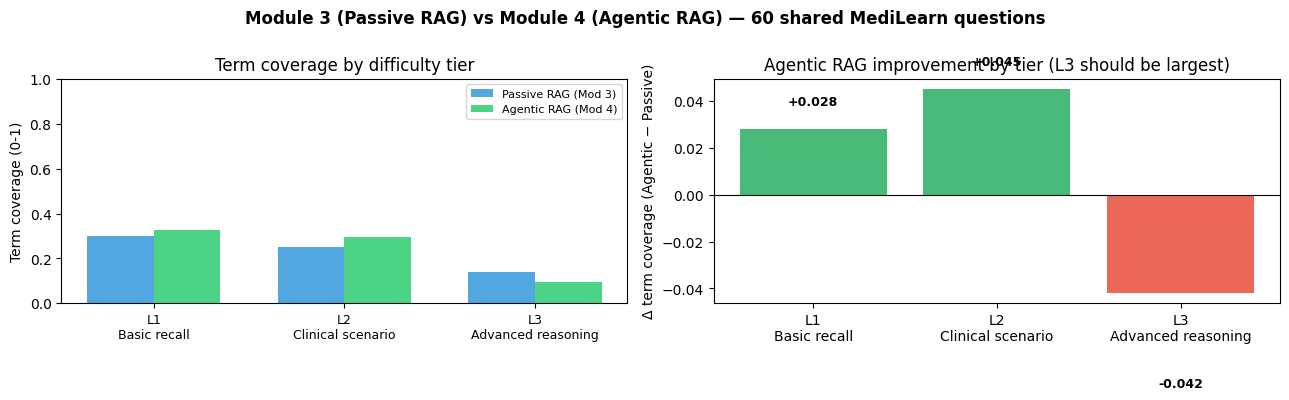

✅ 60-question comparison chart saved


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Module 3 (Passive RAG) vs Module 4 (Agentic RAG) — 60 shared MediLearn questions",
             fontsize=12, fontweight="bold")

tiers = ["L1", "L2", "L3"]
tier_labels = ["L1\nBasic recall", "L2\nClinical scenario", "L3\nAdvanced reasoning"]
x, w = np.arange(3), 0.35

ax = axes[0]
ax.bar(x-w/2, by_diff_passive["term_coverage"], w, label="Passive RAG (Mod 3)", color="#3498db", alpha=0.85)
ax.bar(x+w/2, by_diff_agentic["term_coverage"], w, label="Agentic RAG (Mod 4)", color="#2ecc71", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(tier_labels, fontsize=9)
ax.set_ylabel("Term coverage (0-1)"); ax.set_ylim(0, 1)
ax.set_title("Term coverage by difficulty tier"); ax.legend(fontsize=8)

ax2 = axes[1]
deltas = (by_diff_agentic["term_coverage"] - by_diff_passive["term_coverage"]).round(3)
colours = ["#27ae60" if d >= 0 else "#e74c3c" for d in deltas]
bars = ax2.bar(tier_labels, deltas, color=colours, alpha=0.85)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Δ term coverage (Agentic − Passive)")
ax2.set_title("Agentic RAG improvement by tier (L3 should be largest)")
for bar, d in zip(bars, deltas):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.01 if d>=0 else -0.04),
             f"{d:+.3f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/medilearn_m4_60q.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 60-question comparison chart saved")

### 9.2 Supplementary: Per-Query Spot-Check (5 representative queries)

The original 5-query breakdown — useful for reading specific traces and responses, supplementary to the 60-question run above.

In [28]:
eval_queries = [
    {"id":"E1","category":"treatment",
     "query":"What is the sepsis bundle and when should antibiotics be started?",
     "key_terms":["bundle","antibiotic","hour","cultures","lactate","fluid","vasopressor"]},
    {"id":"E2","category":"diagnosis",
     "query":"How do you diagnose acute myocardial infarction at the bedside?",
     "key_terms":["troponin","ecg","st elevation","pci","reperfusion","ischaemia"]},
    {"id":"E3","category":"pathophysiology",
     "query":"Why does hypokalemia cause cardiac arrhythmias?",
     "key_terms":["potassium","membrane","action potential","ecg","u wave","arrhythmia"]},
    {"id":"E4","category":"guidelines",
     "query":"What is evidence-based treatment for heart failure with reduced ejection fraction?",
     "key_terms":["ace","beta-blocker","mra","ejection fraction","icd","mortality"]},
    {"id":"E5","category":"clinical_pearls",
     "query":"What CSF findings distinguish bacterial from viral meningitis?",
     "key_terms":["glucose","protein","neutrophil","lymphocyte","culture","pcr","gram"]}
]
print(f"✓ Evaluation set: {len(eval_queries)} queries")

✓ Evaluation set: 5 queries


In [29]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

def passive_rag(query: str) -> Dict:
    """Module 3 baseline: embed-retrieve-generate with no reasoning."""
    docs = retrieve(query, top_k=3)
    ctx  = "\n\n".join([d["content"][:300] for d in docs[:3]])
    resp = slm_chat("You are a medical AI. Answer using the context.",
                    f"Context:\n{ctx}\n\nQuestion: {query}\nAnswer:", max_new_tokens=250)
    return {"response": resp, "docs": docs, "avg_sim": float(np.mean([d["similarity"] for d in docs])),
            "trace_steps": 1}

def term_coverage(resp: str, terms: List[str]) -> float:
    r = resp.lower()
    return sum(1 for t in terms if t in r) / len(terms) if terms else 0.0

def semantic_relevance(query: str, resp: str) -> float:
    q_e = embedding_model.encode([query])
    r_e = embedding_model.encode([resp])
    return float(cos_sim(q_e, r_e)[0][0])

print("Running comparative evaluation...")
eval_results = []
for q in eval_queries:
    print(f"  {q['id']} ({q['category']})...", end="", flush=True)
    p  = passive_rag(q["query"])
    a  = run_agentic_rag(q["query"], verbose=False)
    a_avg_sim = float(np.mean([d["similarity"] for d in a["retrieved_docs"]])) if a["retrieved_docs"] else 0
    eval_results.append({
        "id": q["id"], "category": q["category"], "query": q["query"],
        "passive_relevance": semantic_relevance(q["query"], p["response"]),
        "agentic_relevance": semantic_relevance(q["query"], a["generation"]),
        "passive_coverage":  term_coverage(p["response"],    q["key_terms"]),
        "agentic_coverage":  term_coverage(a["generation"],  q["key_terms"]),
        "passive_avg_sim":   p["avg_sim"],
        "agentic_avg_sim":   a_avg_sim,
        "passive_trace":     p["trace_steps"],
        "agentic_trace":     len(a["reasoning_trace"]),
        "agentic_iters":     a["iterations"]
    })
    print(" ✓")
eval_df = pd.DataFrame(eval_results)
print(f"\n✓ Evaluation complete")

Running comparative evaluation...
  E1 (treatment)... ✓
  E2 (diagnosis)... ✓
  E3 (pathophysiology)... ✓
  E4 (guidelines)... ✓
  E5 (clinical_pearls)... ✓

✓ Evaluation complete


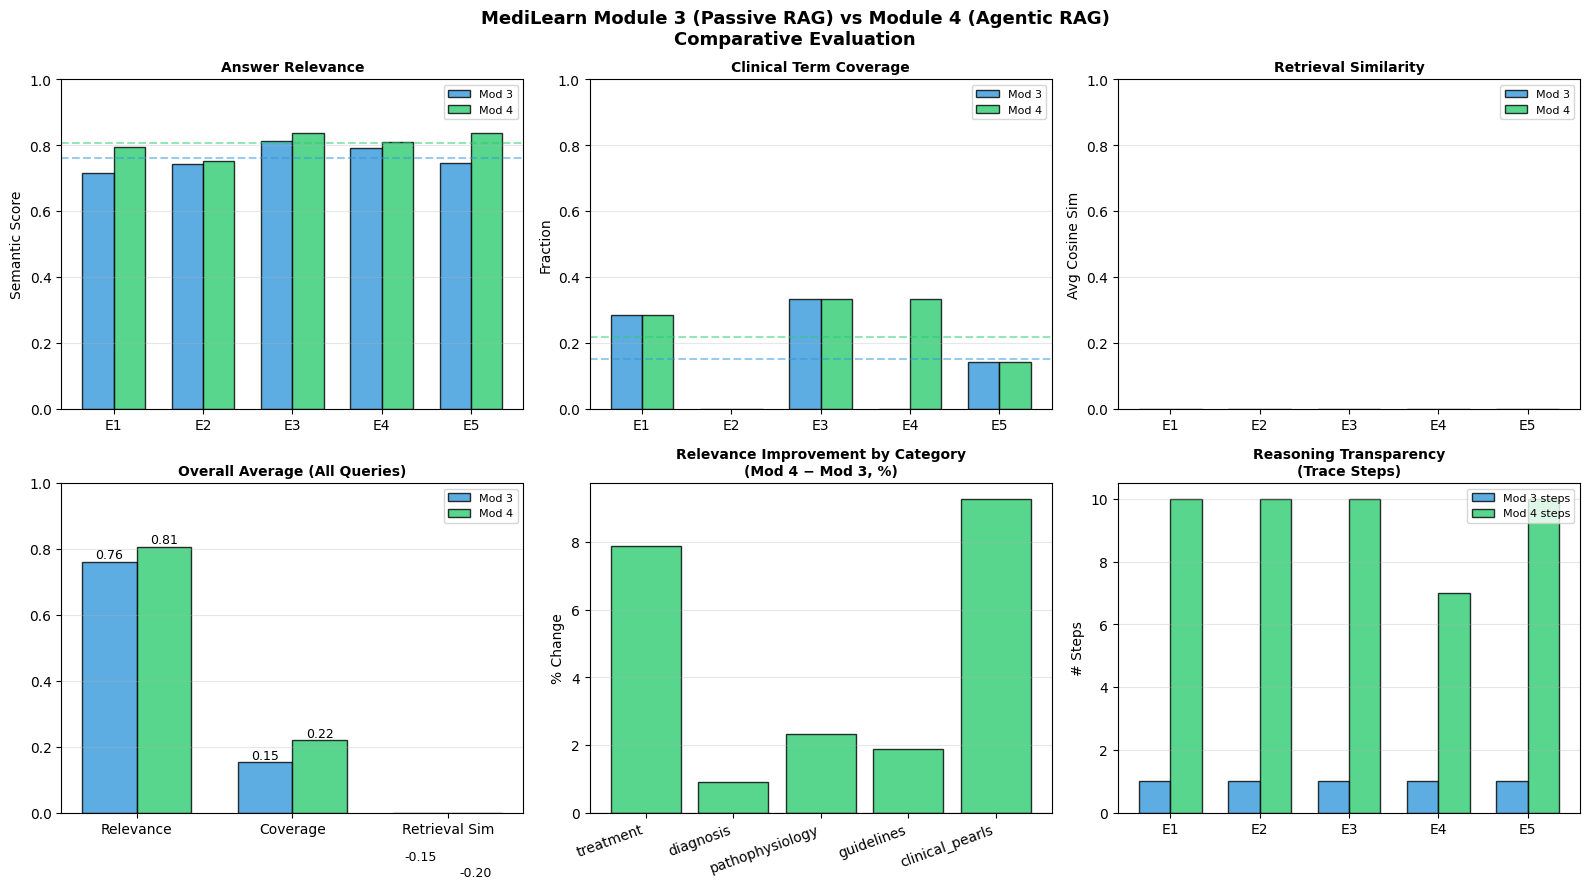

✓ Evaluation plots saved


In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("MediLearn Module 3 (Passive RAG) vs Module 4 (Agentic RAG)\nComparative Evaluation",
             fontsize=13, fontweight="bold")

C3, C4 = "#3498DB", "#2ECC71"
qids   = eval_df["id"].tolist()
x      = np.arange(len(qids))
w      = 0.35

def bar_pair(ax, col3, col4, title, ylabel):
    b3 = ax.bar(x-w/2, eval_df[col3], w, label="Mod 3", color=C3, alpha=0.8, edgecolor="black")
    b4 = ax.bar(x+w/2, eval_df[col4], w, label="Mod 4", color=C4, alpha=0.8, edgecolor="black")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x); ax.set_xticklabels(qids)
    ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    ax.axhline(eval_df[col3].mean(), color=C3, ls="--", alpha=0.5)
    ax.axhline(eval_df[col4].mean(), color=C4, ls="--", alpha=0.5)

bar_pair(axes[0,0], "passive_relevance", "agentic_relevance", "Answer Relevance", "Semantic Score")
bar_pair(axes[0,1], "passive_coverage",  "agentic_coverage",  "Clinical Term Coverage", "Fraction")
bar_pair(axes[0,2], "passive_avg_sim",   "agentic_avg_sim",   "Retrieval Similarity", "Avg Cosine Sim")

# Overall averages
ax = axes[1,0]
metrics = ["Relevance","Coverage","Retrieval Sim"]
m3_avg  = [eval_df["passive_relevance"].mean(), eval_df["passive_coverage"].mean(), eval_df["passive_avg_sim"].mean()]
m4_avg  = [eval_df["agentic_relevance"].mean(), eval_df["agentic_coverage"].mean(), eval_df["agentic_avg_sim"].mean()]
x2 = np.arange(3)
b3 = ax.bar(x2-w/2, m3_avg, w, label="Mod 3", color=C3, alpha=0.8, edgecolor="black")
b4 = ax.bar(x2+w/2, m4_avg, w, label="Mod 4", color=C4, alpha=0.8, edgecolor="black")
for b, v in zip(b3, m3_avg): ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.2f}", ha="center", fontsize=9)
for b, v in zip(b4, m4_avg): ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.2f}", ha="center", fontsize=9)
ax.set_title("Overall Average (All Queries)", fontweight="bold", fontsize=10)
ax.set_xticks(x2); ax.set_xticklabels(metrics); ax.set_ylim(0,1); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# Improvement by category
ax = axes[1,1]
cats = eval_df["category"].unique()
impr = [(eval_df[eval_df["category"]==c]["agentic_relevance"].mean() -
         eval_df[eval_df["category"]==c]["passive_relevance"].mean()) * 100 for c in cats]
colors = ["#2ECC71" if i >= 0 else "#E74C3C" for i in impr]
ax.bar(cats, impr, color=colors, alpha=0.8, edgecolor="black")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Relevance Improvement by Category\n(Mod 4 − Mod 3, %)", fontweight="bold", fontsize=10)
ax.set_ylabel("% Change"); ax.set_xticklabels(cats, rotation=20, ha="right"); ax.grid(axis="y", alpha=0.3)

# Reasoning transparency
ax = axes[1,2]
ax.bar(x-w/2, eval_df["passive_trace"], w, label="Mod 3 steps", color=C3, alpha=0.8, edgecolor="black")
ax.bar(x+w/2, eval_df["agentic_trace"], w, label="Mod 4 steps", color=C4, alpha=0.8, edgecolor="black")
ax.set_title("Reasoning Transparency\n(Trace Steps)", fontweight="bold", fontsize=10)
ax.set_ylabel("# Steps"); ax.set_xticks(x); ax.set_xticklabels(qids); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/medilearn_m4_eval.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Evaluation plots saved")

In [31]:
# ── Print Summary Table ────────────────────────────────────────────────────────
def delta(a, b):
    pct = (b - a) / max(abs(a), 1e-6) * 100
    return f"{'▲' if pct >= 0 else '▼'} {abs(pct):.1f}%"

m3r, m4r = eval_df["passive_relevance"].mean(), eval_df["agentic_relevance"].mean()
m3c, m4c = eval_df["passive_coverage"].mean(),  eval_df["agentic_coverage"].mean()
m3s, m4s = eval_df["passive_avg_sim"].mean(),   eval_df["agentic_avg_sim"].mean()

print("=" * 70)
print("EVALUATION SUMMARY: Module 3 (Passive RAG) vs Module 4 (Agentic RAG)")
print("=" * 70)
print(f"{'Metric':<30} {'Mod 3':>10} {'Mod 4':>10} {'Change':>12}")
print("-" * 70)
print(f"{'Answer Relevance':<30} {m3r:>10.3f} {m4r:>10.3f} {delta(m3r,m4r):>12}")
print(f"{'Clinical Term Coverage':<30} {m3c:>10.3f} {m4c:>10.3f} {delta(m3c,m4c):>12}")
print(f"{'Retrieval Similarity':<30} {m3s:>10.3f} {m4s:>10.3f} {delta(m3s,m4s):>12}")
print(f"{'Reasoning Steps (avg)':<30} {eval_df['passive_trace'].mean():>10.1f} {eval_df['agentic_trace'].mean():>10.1f} {'(transparency)':>12}")
print(f"{'Retrieval Loops (avg)':<30} {'1.0':>10} {eval_df['agentic_iters'].mean():>10.1f} {'(adaptive)':>12}")
print("=" * 70)

EVALUATION SUMMARY: Module 3 (Passive RAG) vs Module 4 (Agentic RAG)
Metric                              Mod 3      Mod 4       Change
----------------------------------------------------------------------
Answer Relevance                    0.762      0.807       ▲ 5.8%
Clinical Term Coverage              0.152      0.219      ▲ 43.7%
Retrieval Similarity               -0.154     -0.202      ▼ 31.0%
Reasoning Steps (avg)                 1.0        9.4 (transparency)
Retrieval Loops (avg)                 1.0        2.8   (adaptive)


---

# Section 10: Educational Discussion

## Module 3 → Module 4: What Changed and Why

### Passive RAG (Module 3)
A fixed pipeline with no decision-making:
```
query → embed → top-K retrieve → format prompt → generate
```
It answered questions reliably but could not:
- Reason about retrieval quality
- Ask clarifying questions
- Remember a student's history
- Simulate evolving clinical scenarios

### Agentic RAG + Multi-Agent (Module 4)
A graph of reasoning agents where each node can **think, act, and observe**.

#### Agentic RAG Core — What's new
- **Query rewriting**: The agent rewrites the student's question into retrieval-optimised medical terminology before embedding
- **Relevance grading**: After retrieval, checks "are these documents actually sufficient?" and loops if not
- **ReAct loop**: Reason → Act → Observe — the agent can revise its own strategy mid-flight
- **Reasoning trace**: Every step is logged — the system explains what it did and why

#### Diagnostic Reasoner — What's new
- **Multi-turn statefulness**: Remembers what it asked in previous turns
- **Socratic method**: Deliberately withholds the answer to build clinical reasoning skills
- **Evidence-grounded differential**: Every question is backed by retrieved real-world cases

#### Study Planner — What's new
- **Persistent student model**: Tracks accuracy per topic across sessions
- **Targeted retrieval**: Retrieves resources specifically for weak topics, not a generic search
- **Adaptive planning**: The plan changes as the student's performance changes

#### Clinical Simulator — What's new
- **Patient state machine**: Maintains full patient vitals and labs across turns
- **Consequence engine**: Student actions have realistic, evidence-grounded effects
- **Teaching feedback loop**: After each action, explains what happened and cites the evidence

#### Orchestrator — What's new
- **Intent detection**: Understands what the student *wants* (not just what they *said*)
- **Multi-agent delegation**: Routes to the right specialist rather than handling everything in one chain

---

## LangGraph: The Technical Backbone

LangGraph enables all of the above by expressing agent behaviour as a **typed state graph**:

- `StateGraph` ensures all agents share typed, explicit state — no hidden side effects
- `add_conditional_edges` enables runtime branching (retry, route, skip)
- **Cycles** allow loops — the Agentic RAG can retry retrieval; the Diagnostic Reasoner can continue dialogue
- **Composability** — each agent is its own sub-graph, the Orchestrator composes them

---

## Limitations & Next Steps

| Limitation | Production Solution |
|---|---|
| SmolLM-135M has limited reasoning | Fine-tune Mistral-7B or Llama-3-8B on medical data |
| In-memory student state | Postgres/MongoDB for persistent session storage |
| Rule-based patient consequences | Learned consequence model from clinical outcome data |
| Single-user sessions | Per-user session manager with Redis |
| No feedback loop | RLHF on student ratings of agent responses |

---

## Module Progression Complete

| Module | Built | Key Concept |
|---|---|---|
| 1 | SLM benchmarking | Model selection |
| 2 | Medical fine-tuning | Domain adaptation |
| 3 | Passive RAG | Retrieval grounding |
| **4** | **Agentic RAG + 4 agents + Orchestrator** | **Reasoning, planning, statefulness** |

**MediLearn is now a genuine AI teaching assistant** — not just a question answerer.


---

# Section 11: Save Results

In [32]:
import os

out_dir = "/content/medilearn_module4_outputs"
os.makedirs(out_dir, exist_ok=True)

# 60-question results (the primary cross-module comparable artifact)
passive_60_df.to_json(os.path.join(DRIVE_RESULTS_DIR, "module4_passive_rag_60q.json"), orient="records", indent=2)
agentic_60_df.to_json(os.path.join(DRIVE_RESULTS_DIR, "module4_agentic_rag_60q.json"), orient="records", indent=2)

with open(os.path.join(DRIVE_RESULTS_DIR, "module4_summary.json"), "w") as f:
    json.dump({
        "overall": {"passive": overall_passive.to_dict(), "agentic": overall_agentic.to_dict()},
        "by_difficulty_term_coverage": tier_compare.to_dict(orient="index"),
        "lift_term_coverage": round(float(lift), 3),
    }, f, indent=2)

# Original 5-query CSV (supplementary)
eval_df.to_csv(f"{out_dir}/module4_5query_spotcheck.csv", index=False)

with open(f"{out_dir}/student_performance.json", "w") as f:
    json.dump(STUDENT_DB, f, indent=2, default=str)

print("\u2705 Results saved:")
print(f"   Drive \u2192 {DRIVE_RESULTS_DIR}/module4_*.json  (60-question, cross-module comparable)")
print(f"   Local \u2192 {out_dir}/module4_5query_spotcheck.csv  (per-query traces)")

print("\n" + "="*65)
print("MEDILEARN MODULE 4 — COMPLETE")
print("="*65)
print("\nAgents built:")
print("  \u2713 Agentic RAG Core    — query rewriting, self-reflection, retrieval loop")
print("  \u2713 Diagnostic Reasoner — Socratic multi-turn clinical reasoning")
print("  \u2713 Study Planner       — stateful personalised learning paths")
print("  \u2713 Clinical Simulator  — consequence-driven patient simulation")
print("  \u2713 Orchestrator        — multi-agent LangGraph routing")
print(f"\n60-question comparison (term coverage):")
print(f"  Passive RAG  : {overall_passive['term_coverage']:.3f}")
print(f"  Agentic RAG  : {overall_agentic['term_coverage']:.3f}")
print(f"  Delta        : {lift:+.3f} (\'L3 advanced reasoning\' should show the largest gain)")
print("\n\u27A1\uFE0F  Module 6 loads the same fine-tuned model, quantizes it to GGUF, and re-runs")
print("     the 60-question eval to show the quantization accuracy/latency trade-off.")
print("="*65)

✅ Results saved:
   Drive → /content/drive/MyDrive/SLM Workshop/eval/results/module4_*.json  (60-question, cross-module comparable)
   Local → /content/medilearn_module4_outputs/module4_5query_spotcheck.csv  (per-query traces)

MEDILEARN MODULE 4 — COMPLETE

Agents built:
  ✓ Agentic RAG Core    — query rewriting, self-reflection, retrieval loop
  ✓ Diagnostic Reasoner — Socratic multi-turn clinical reasoning
  ✓ Study Planner       — stateful personalised learning paths
  ✓ Clinical Simulator  — consequence-driven patient simulation
  ✓ Orchestrator        — multi-agent LangGraph routing

60-question comparison (term coverage):
  Passive RAG  : 0.232
  Agentic RAG  : 0.246
  Delta        : +0.014 ('L3 advanced reasoning' should show the largest gain)

➡️  Module 6 loads the same fine-tuned model, quantizes it to GGUF, and re-runs
     the 60-question eval to show the quantization accuracy/latency trade-off.
